In [1]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.ensemble import IsolationForest

In [ ]:
def classifier(time_freq, results_df):
    computed_data = pd.read_csv(f'/Users/jakelukasik/Desktop/School/Spring 2025/DS 340W/Implementation/PAPER2/features_{time_freq}.csv', parse_dates=['date'])

    features = ['std_rush_order',
                'avg_rush_order',
                'std_trades',
                'std_volume',
                'avg_volume',
                'std_price',
                'avg_price',
                'avg_price_max',
                'hour_sin',
                'hour_cos',
                'minute_sin',
                'minute_cos']

    X = computed_data[features]
    Y = computed_data['gt'].astype(int).values.ravel()

    # Standardize the features; this will help us get a better performance in our models
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    classifiers = [
        ('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=5, random_state=1)),
        ('AdaBoost', AdaBoostClassifier(DecisionTreeClassifier(max_depth=5), n_estimators=100, learning_rate=0.5, random_state=0)),
        ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=1)),
        ('XGBoost', xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=1, use_label_encoder=False, eval_metric='logloss'))
    ]

    cv_list = [5]
    processes = 7

    for clf_name, clf in classifiers:
        print(f"Processing: {clf_name} - {time_freq}")
        
        # Run the cross validation predictions
        y_pred = cross_val_predict(clf, X_scaled, Y.ravel(), cv=StratifiedKFold(n_splits=cv_list[0]), n_jobs=processes)
        
        # Calculate metrics
        recall = recall_score(Y, y_pred)
        precision = precision_score(Y, y_pred)
        f1 = f1_score(Y, y_pred)
        roc_auc = roc_auc_score(Y, y_pred)

        # Store results in DataFrame
        results_df = results_df.append({
            'Model': clf_name,
            'Time Frequency': time_freq,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'ROC-AUC': roc_auc
        }, ignore_index=True)

        # Display evaluation metrics
        print(f'Recall: {recall}')
        print(f'Precision: {precision}')
        print(f'F1 score: {f1}')
        print(f'ROC-AUC: {roc_auc}')

        # Plot ROC curve
        fpr, tpr, _ = roc_curve(Y, y_pred)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'{clf_name} (ROC curve)')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {clf_name} ({time_freq})')
        plt.legend(loc="lower right")
        plt.show()

        # Precision-Recall curve
        precision_vals, recall_vals, _ = precision_recall_curve(Y, y_pred)
        plt.figure(figsize=(8, 6))
        plt.plot(recall_vals, precision_vals, label=f'{clf_name} (PR curve)')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'Precision-Recall Curve - {clf_name} ({time_freq})')
        plt.legend(loc="lower left")
        plt.show()

        # If it's a Random Forest then we also plot feature importances
        if clf_name == 'Random Forest':
            clf.fit(X_scaled, Y)
            feature_importances = clf.feature_importances_

            # Sort feature importances
            importance_df = pd.DataFrame({
                'Feature': features,
                'Importance': feature_importances
            })

            importance_df = importance_df.sort_values(by='Importance', ascending=False)

            # Plot feature importances
            plt.figure(figsize=(10, 6))
            plt.barh(importance_df['Feature'], importance_df['Importance'], color='royalblue')
            plt.xlabel('Importance')
            plt.title(f'Feature Importance - Random Forest ({time_freq})')
            plt.show()

        computed_data['predicted_gt'] = y_pred
        detected_pump_dump = computed_data[computed_data['predicted_gt'] == 1]
        
        if not detected_pump_dump.empty:
            plt.figure(figsize=(14, 8))
            plt.plot(computed_data['date'], computed_data['avg_price'], label='Avg Price', color='blue', alpha=0.7)
            plt.scatter(detected_pump_dump['date'], detected_pump_dump['avg_price'], color='red', label='Detected Pump and Dump', marker='x')
            plt.title(f'Pump and Dump Detection - {clf_name} ({time_freq})')
            plt.xlabel('Time')
            plt.ylabel('Average Price')
            plt.legend(loc="upper left")
            plt.show()

    return results_df

Processing: Random Forest - 25S
Recall: 0.889589905362776
Precision: 0.9657534246575342
F1 score: 0.9261083743842365
ROC-AUC: 0.9447845757927943


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/2606966685.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


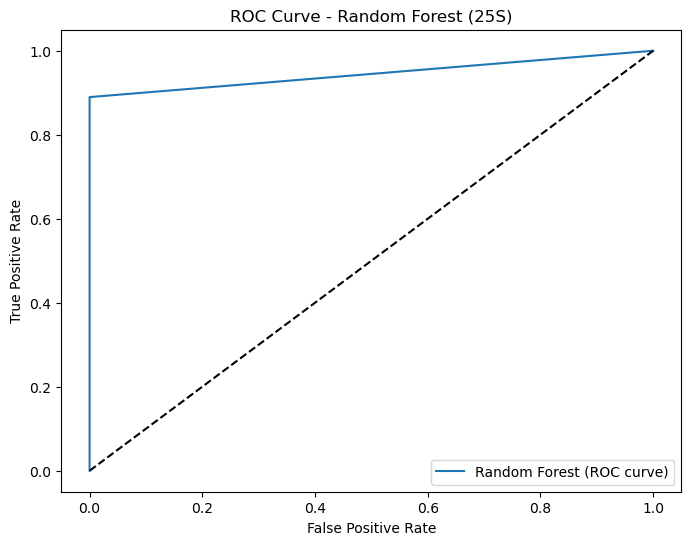

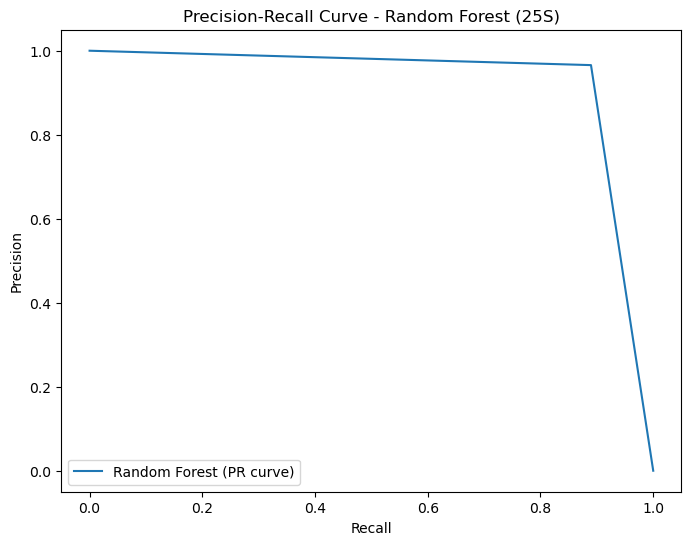

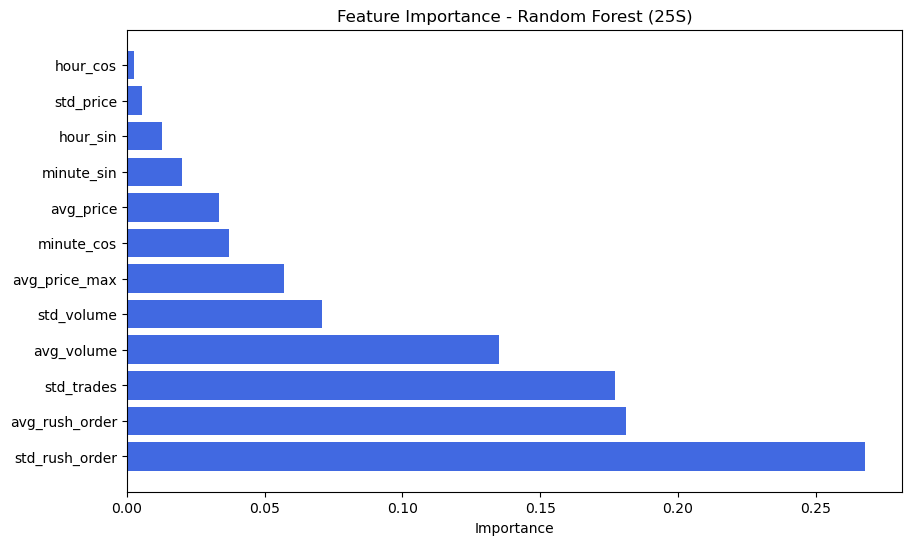

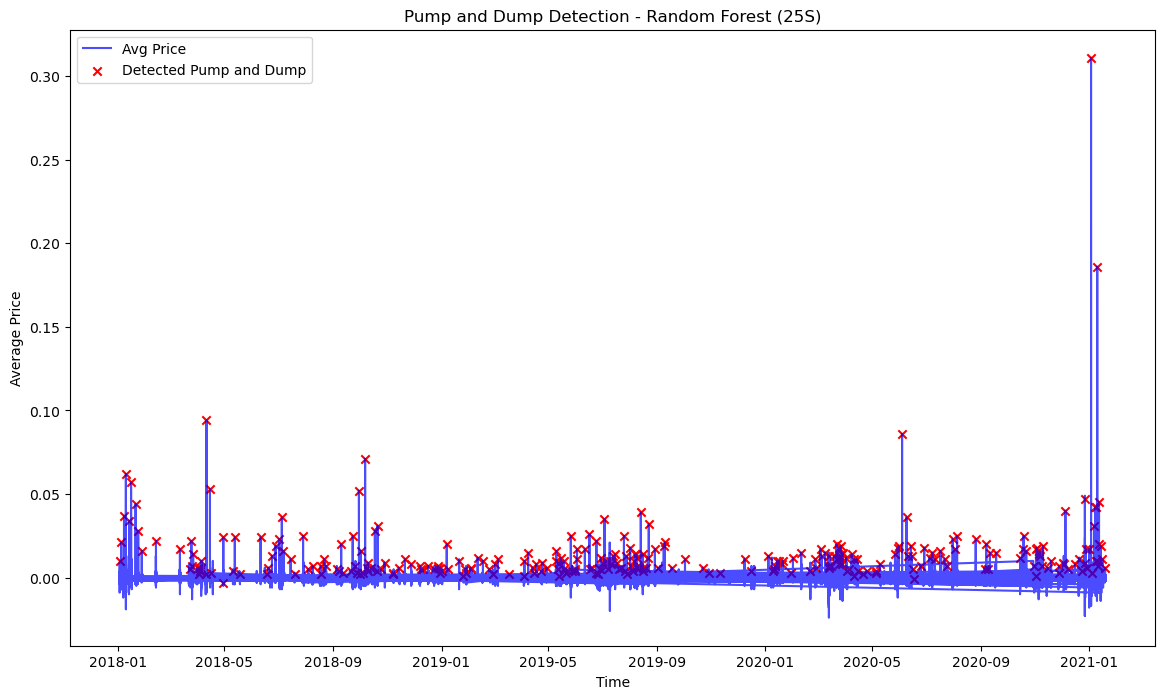

Processing: AdaBoost - 25S
Recall: 0.9085173501577287
Precision: 0.9290322580645162
F1 score: 0.9186602870813397
ROC-AUC: 0.9542358459239582


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/2606966685.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


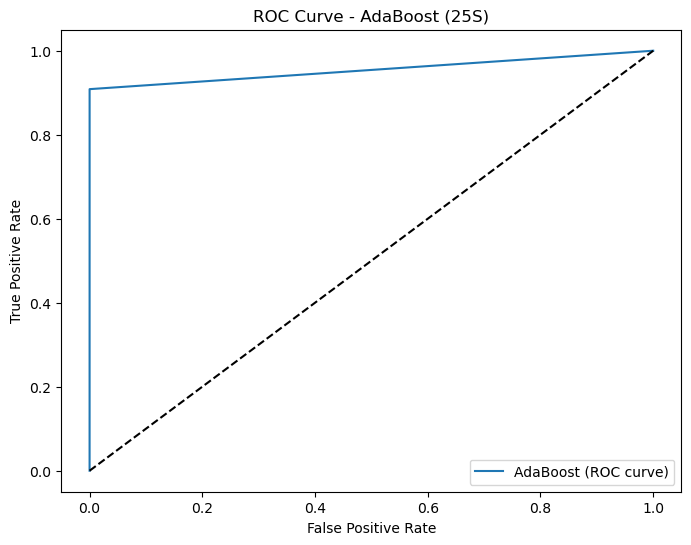

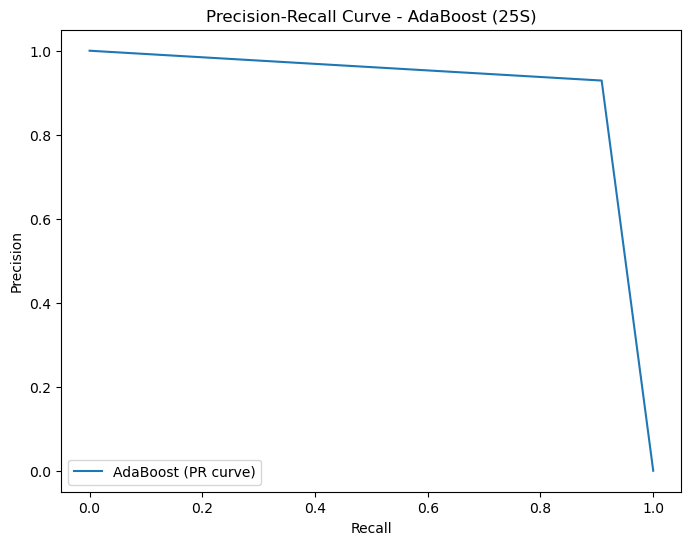

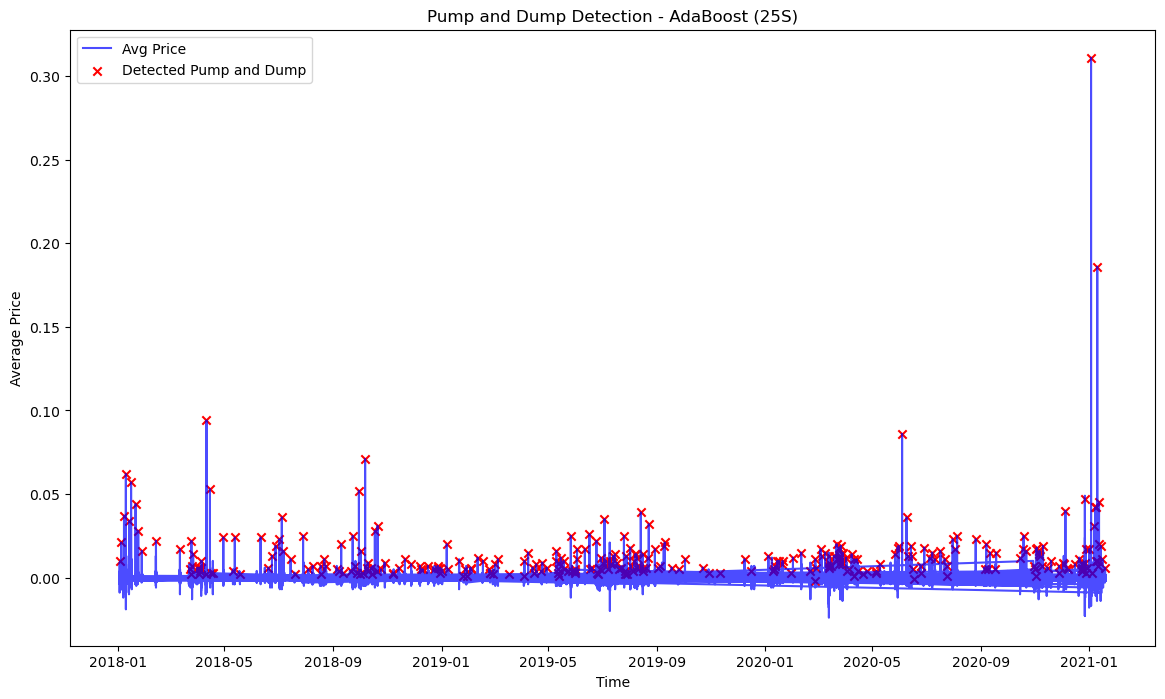

Processing: Gradient Boosting - 25S
Recall: 0.7097791798107256
Precision: 0.8687258687258688
F1 score: 0.78125
ROC-AUC: 0.8548543084841441


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/2606966685.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


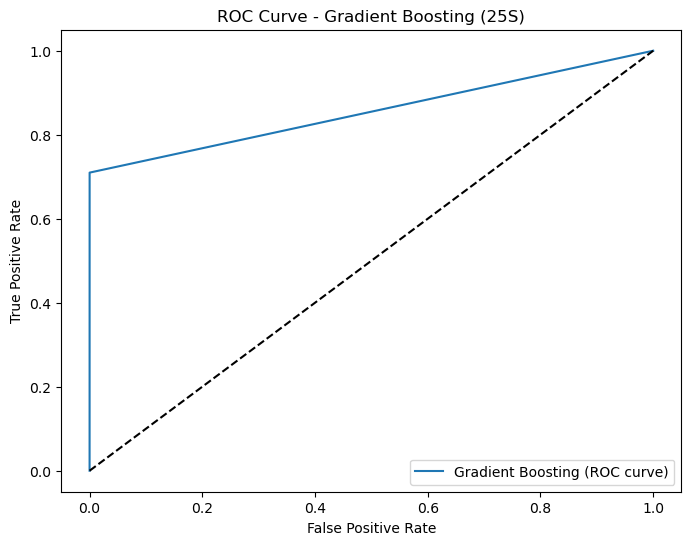

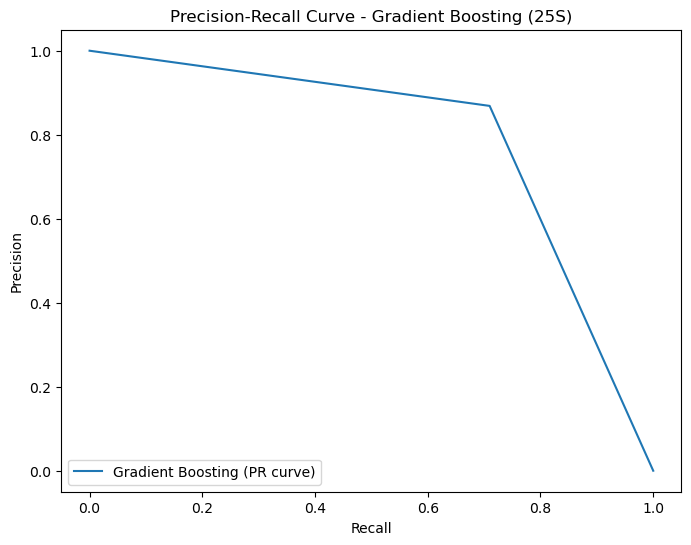

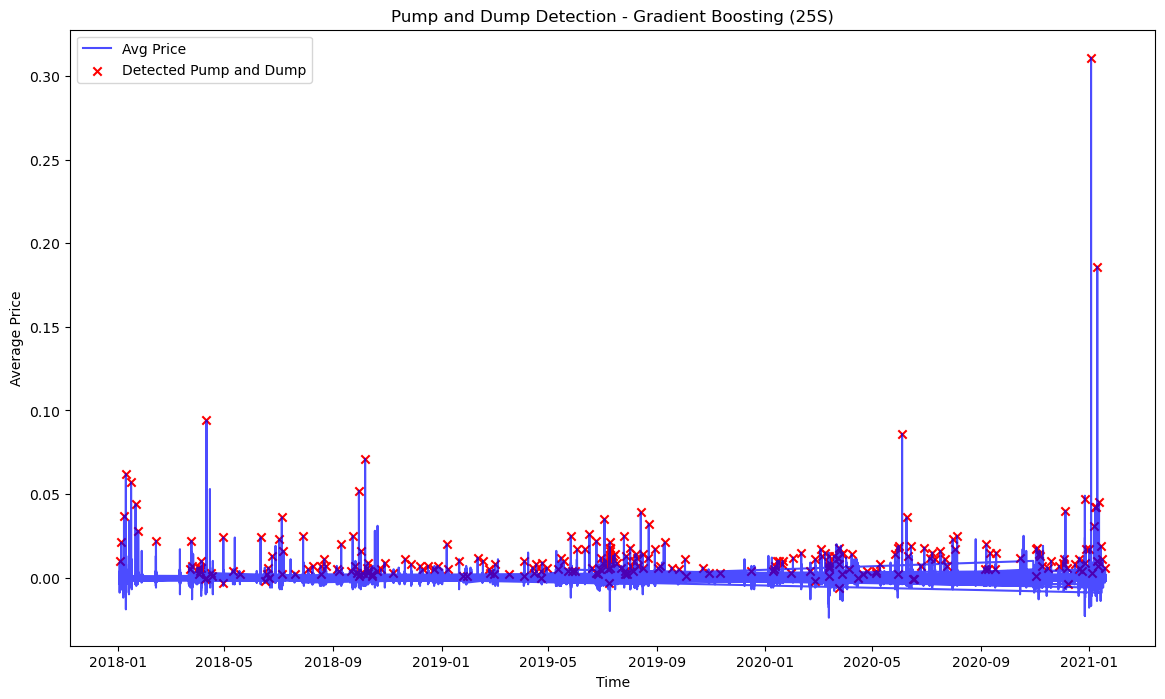

Processing: XGBoost - 25S


/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:53:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:53:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:53:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:53:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warni

Recall: 0.8706624605678234
Precision: 0.8761904761904762
F1 score: 0.8734177215189874
ROC-AUC: 0.9352907604183961


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/2606966685.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


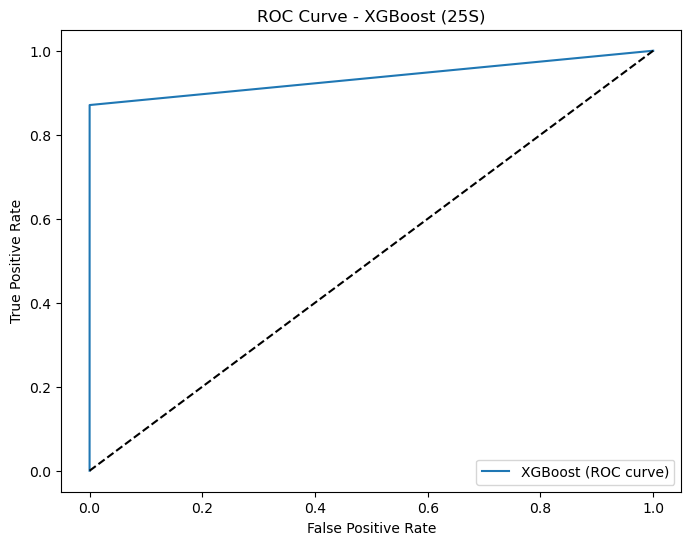

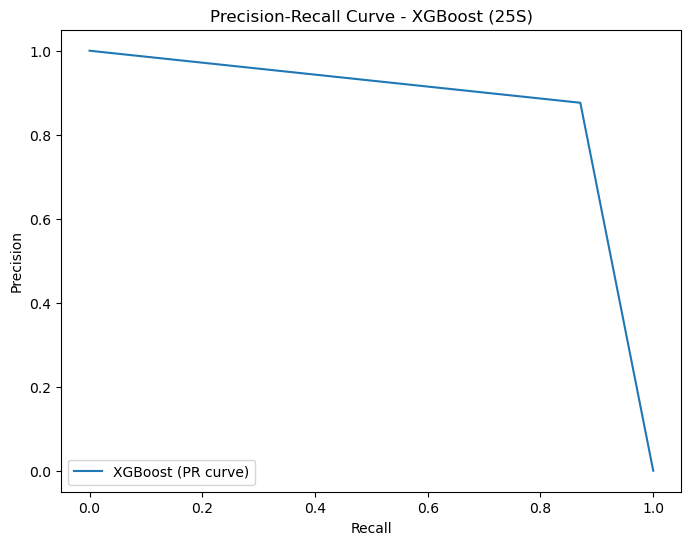

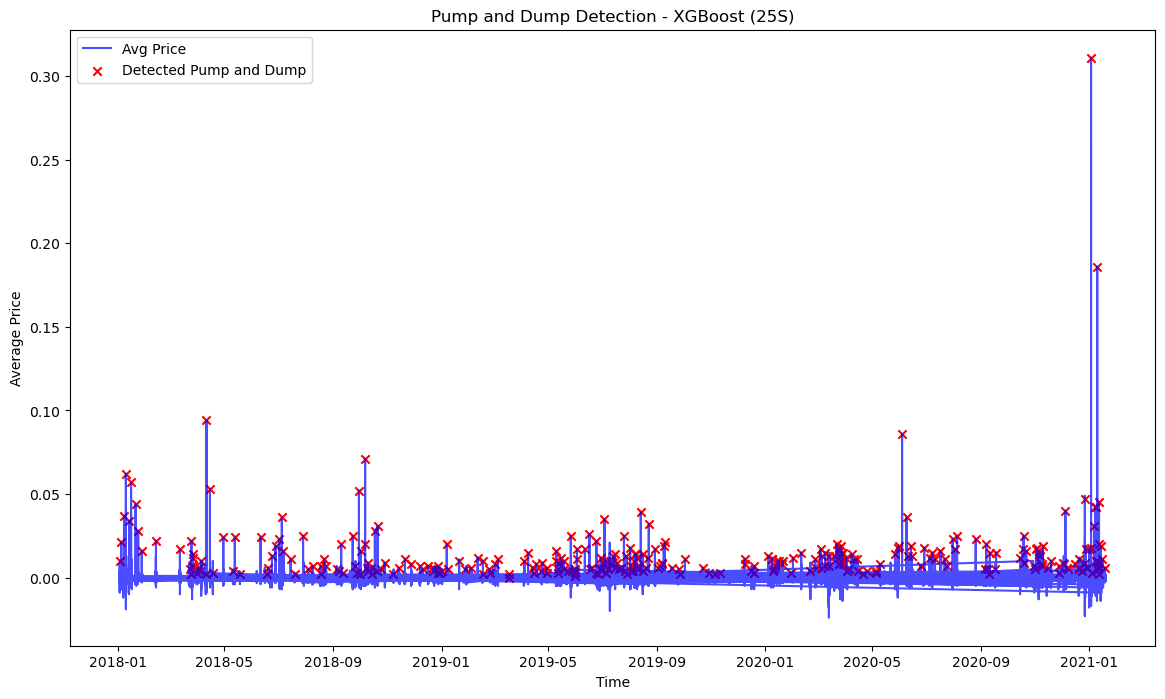

In [43]:
results_df = pd.DataFrame(columns=['Model', 'Time Frequency', 'Recall', 'Precision', 'F1 Score', 'ROC-AUC'])

start = datetime.datetime.now()
results_df = classifier(time_freq='25S', results_df=results_df)


Processing: Random Forest - 15S
Recall: 0.8548895899053628
Precision: 0.9678571428571429
F1 score: 0.9078726968174204
ROC-AUC: 0.927437086661815


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/2606966685.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


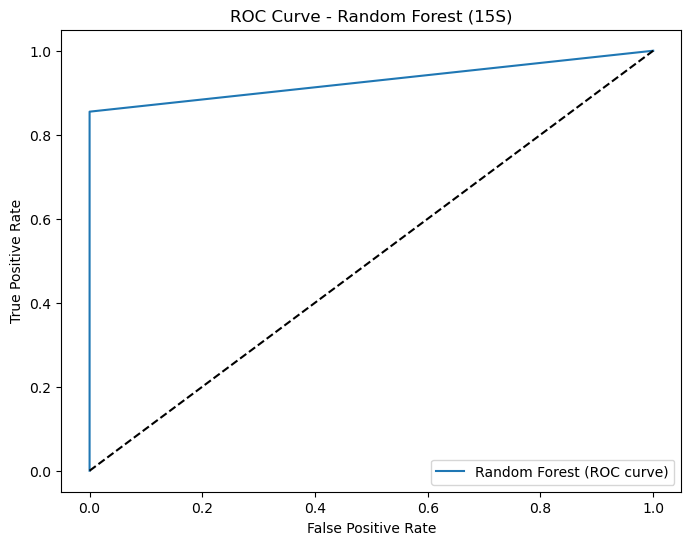

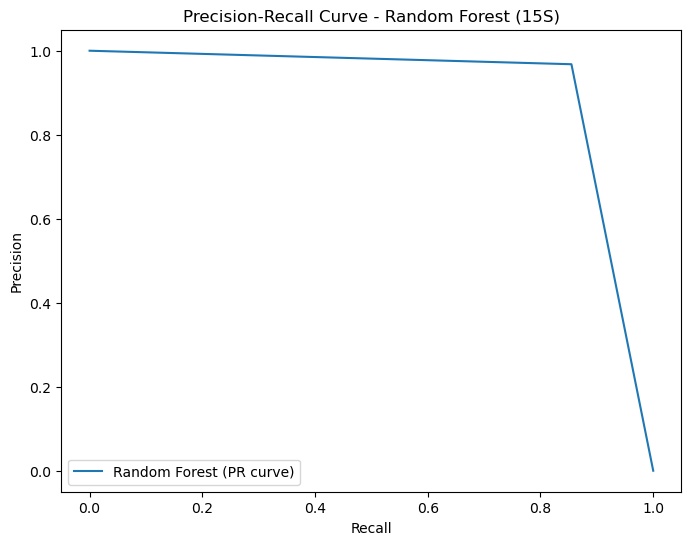

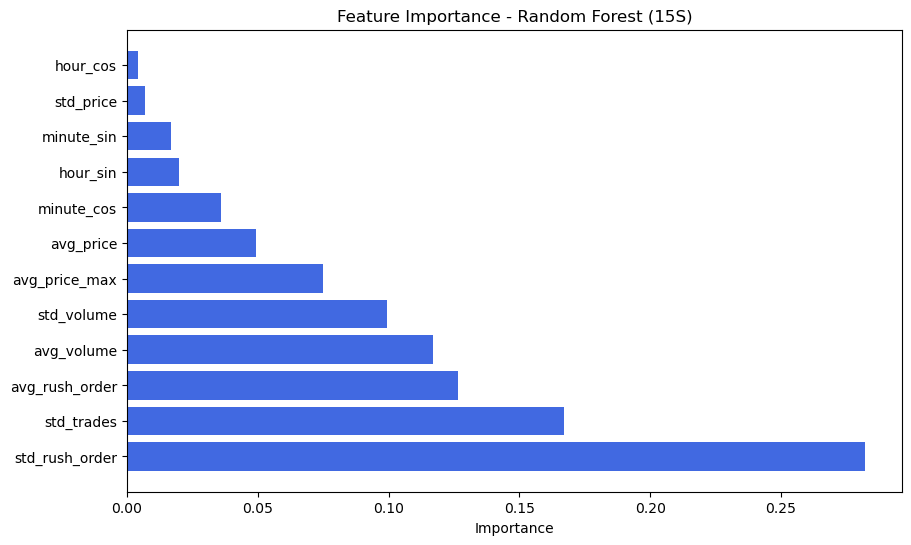

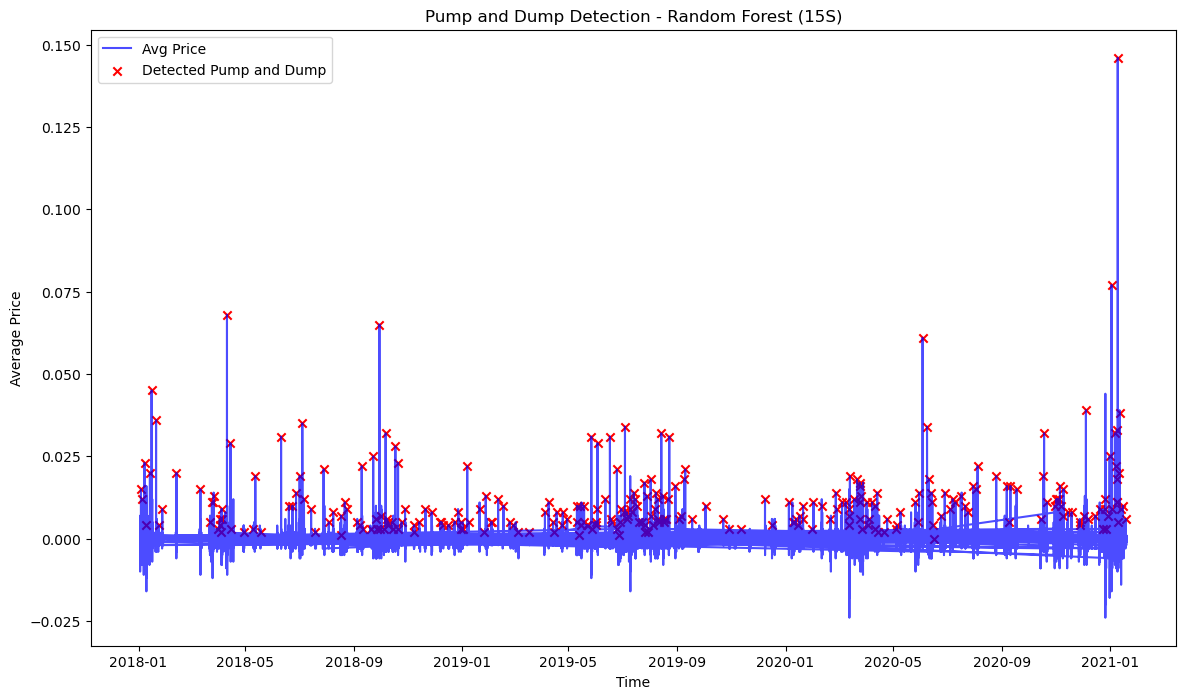

Processing: AdaBoost - 15S
Recall: 0.8801261829652997
Precision: 0.9207920792079208
F1 score: 0.8999999999999999
ROC-AUC: 0.9400425360403395


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/2606966685.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


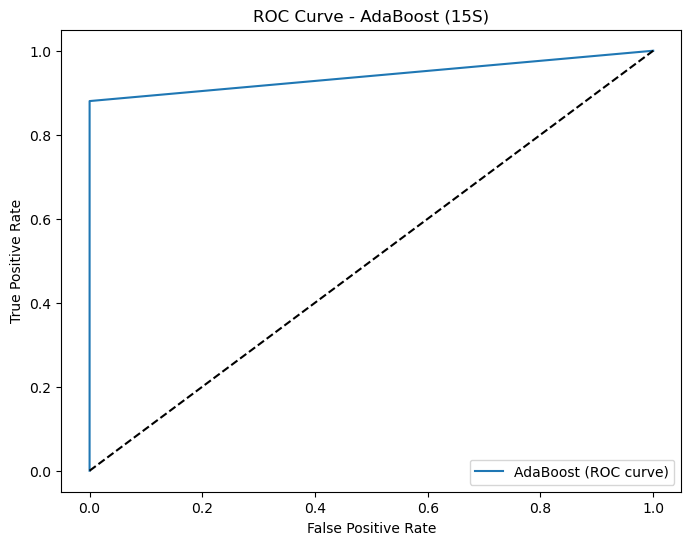

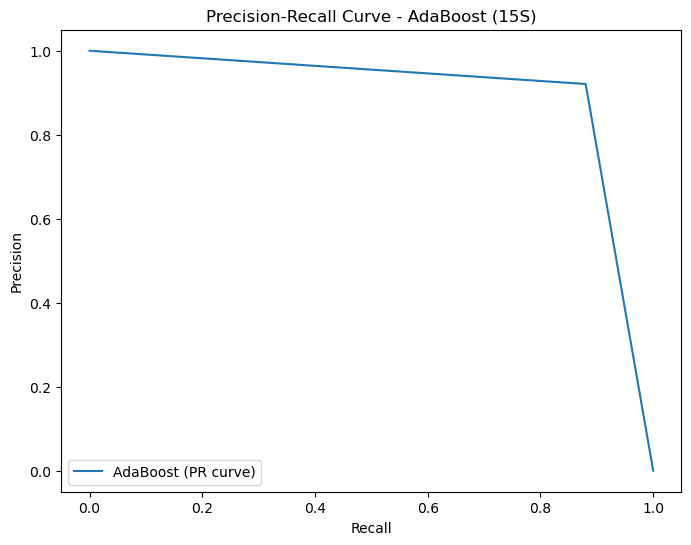

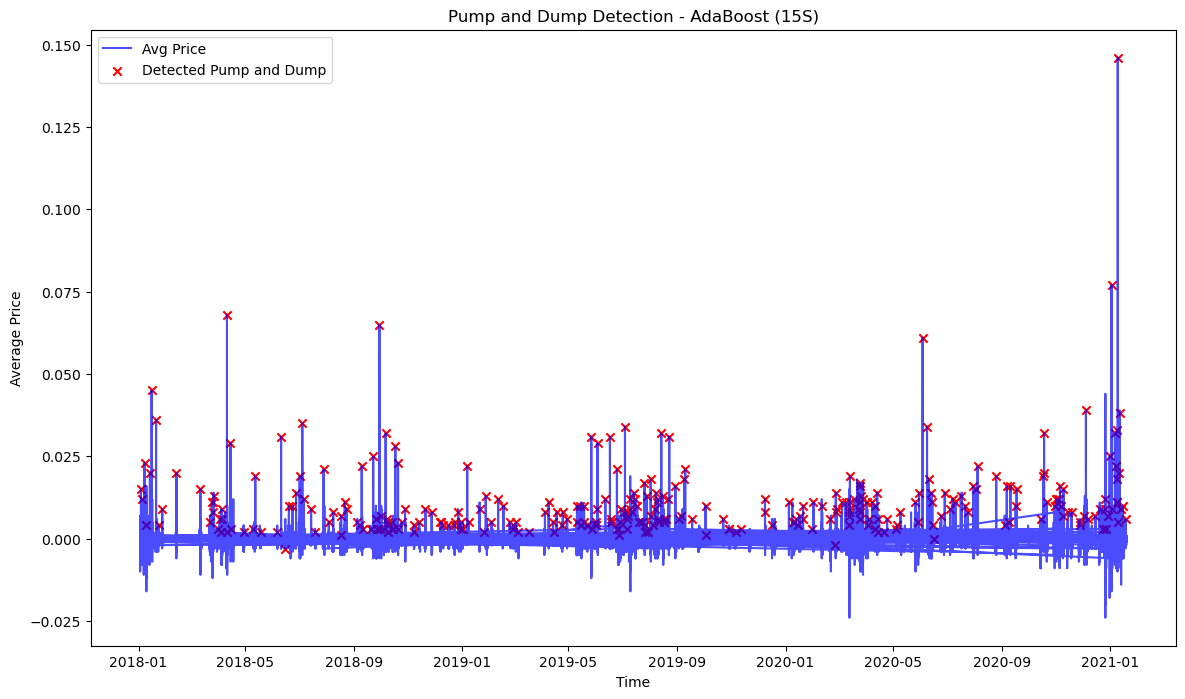

Processing: Gradient Boosting - 15S
Recall: 0.25236593059936907
Precision: 0.3252032520325203
F1 score: 0.2841918294849023
ROC-AUC: 0.6260407901570384


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/2606966685.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


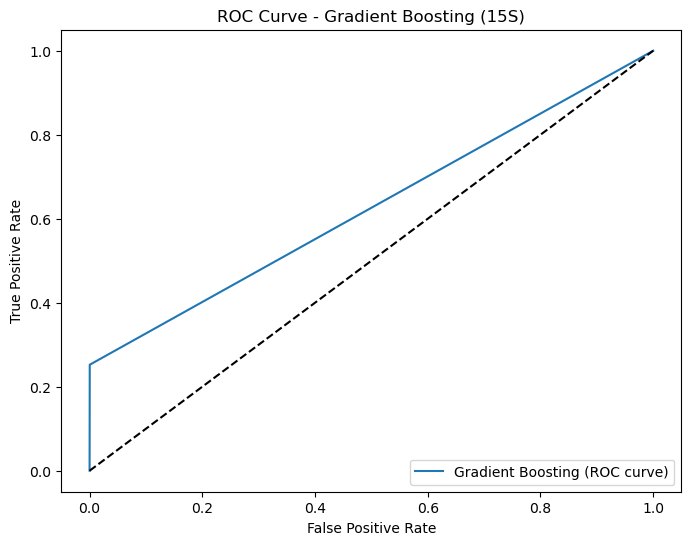

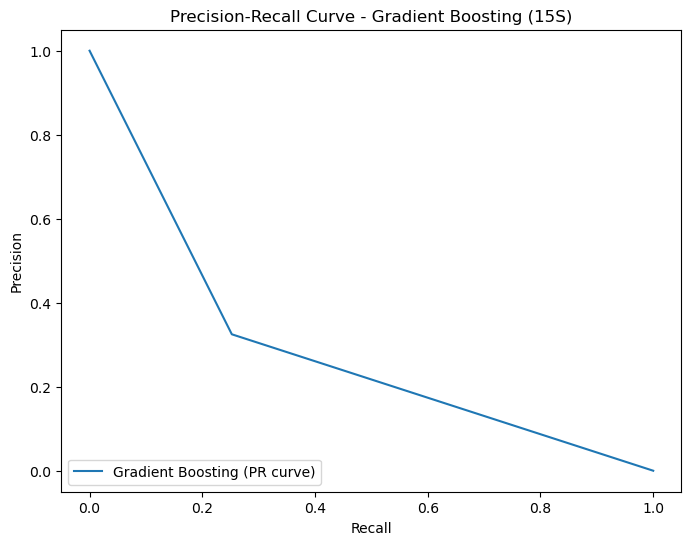

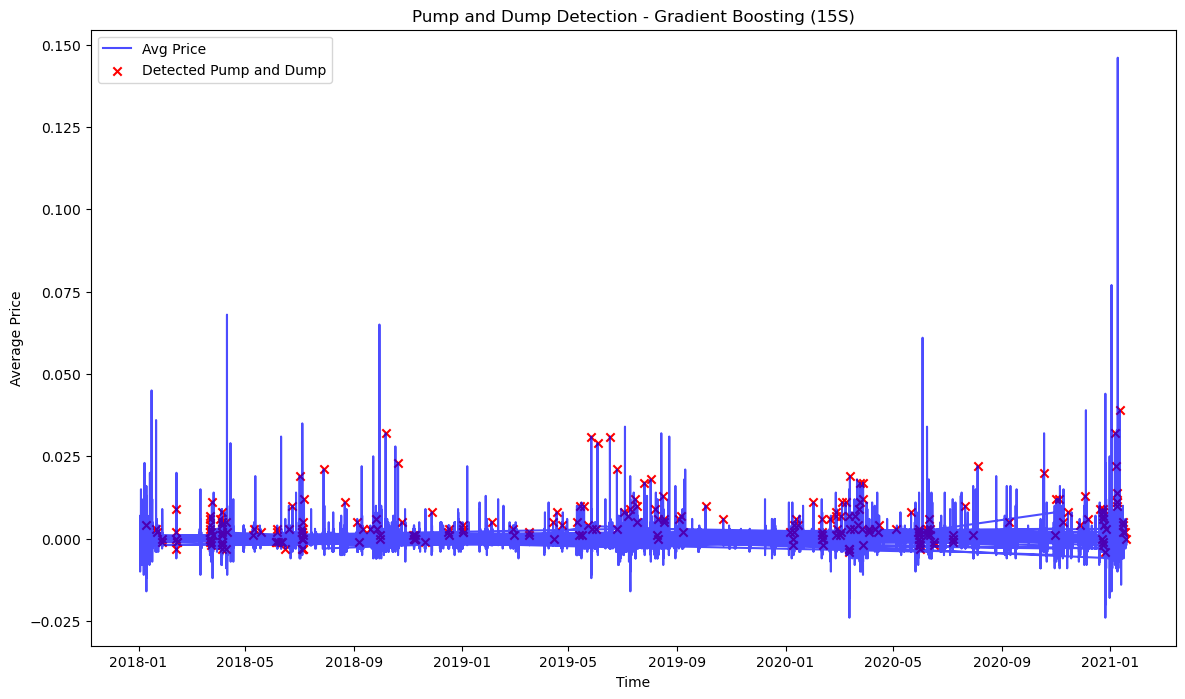

Processing: XGBoost - 15S


/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:59:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:59:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:59:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [15:59:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warni

Recall: 0.8391167192429022
Precision: 0.8184615384615385
F1 score: 0.8286604361370716
ROC-AUC: 0.9195078274924384


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/2606966685.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


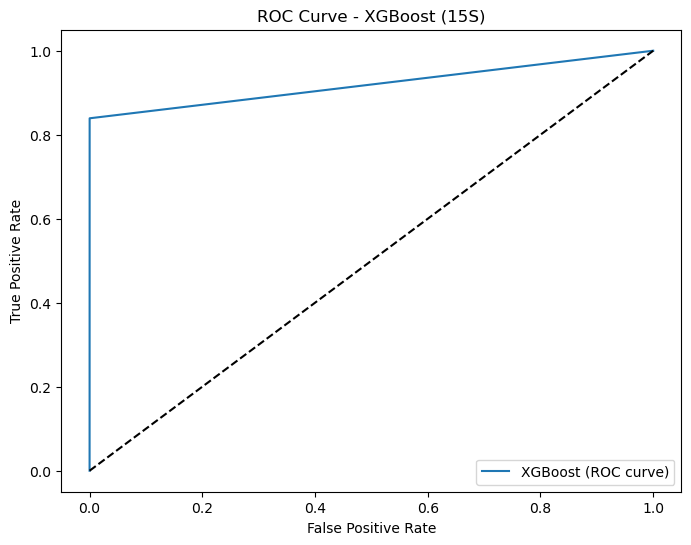

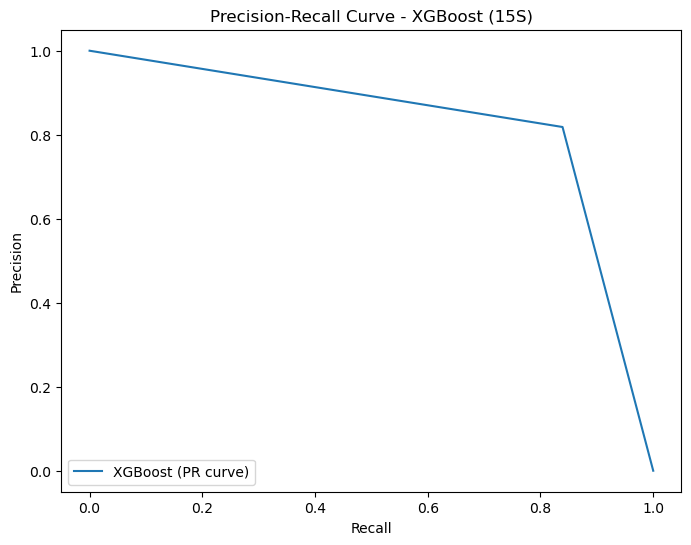

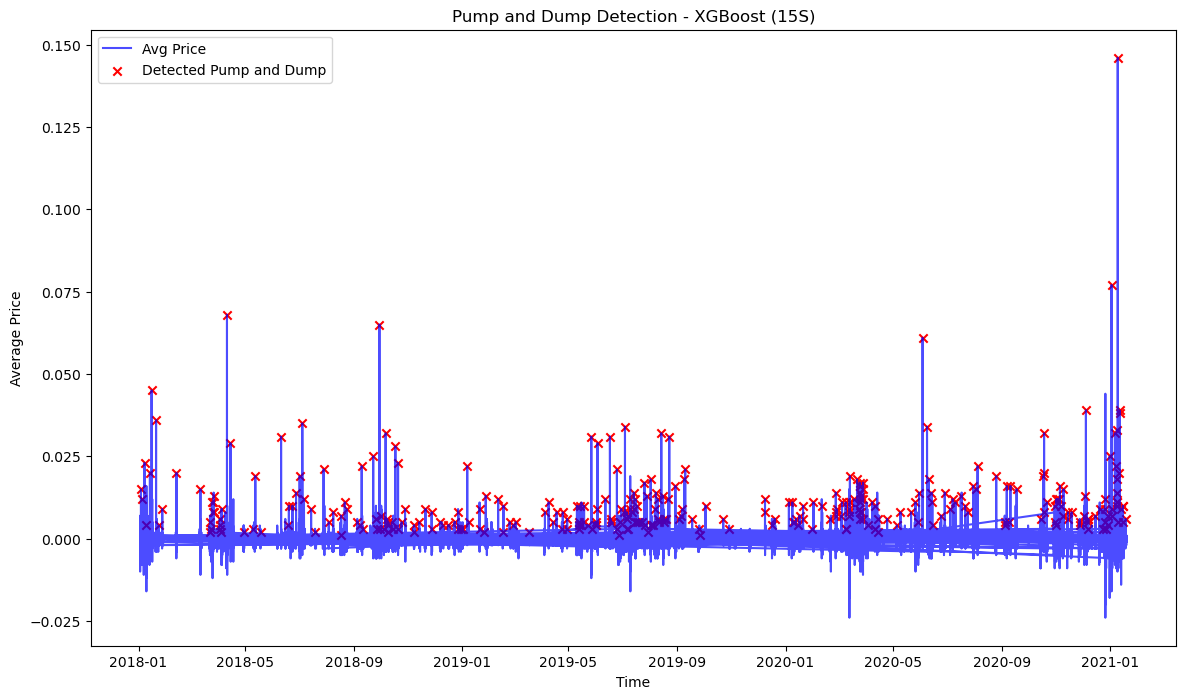

In [44]:
results_df = classifier(time_freq='15S', results_df=results_df)

Processing: Random Forest - 5S
Recall: 0.7350157728706624
Precision: 0.9471544715447154
F1 score: 0.827708703374778
ROC-AUC: 0.8674999691647187


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/2606966685.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


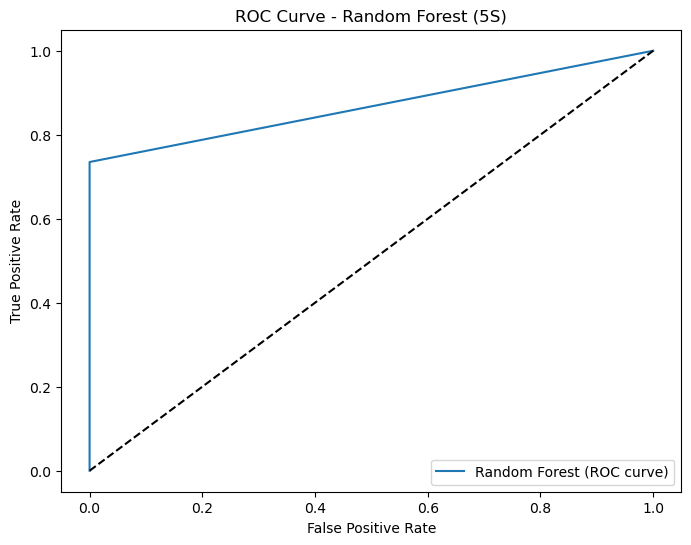

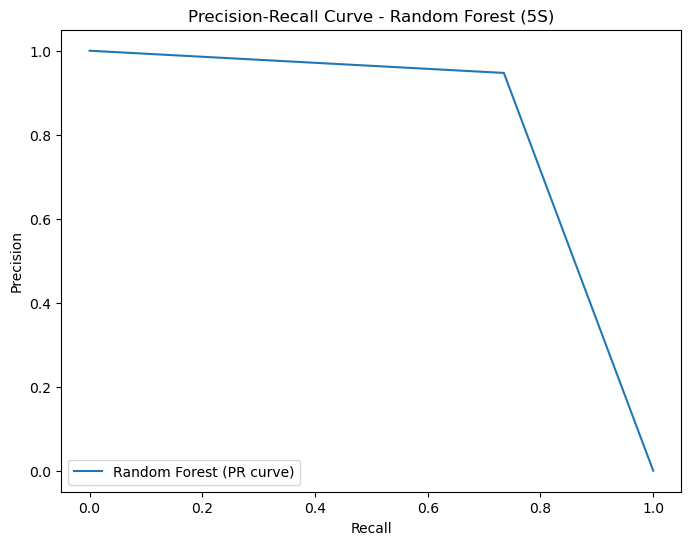

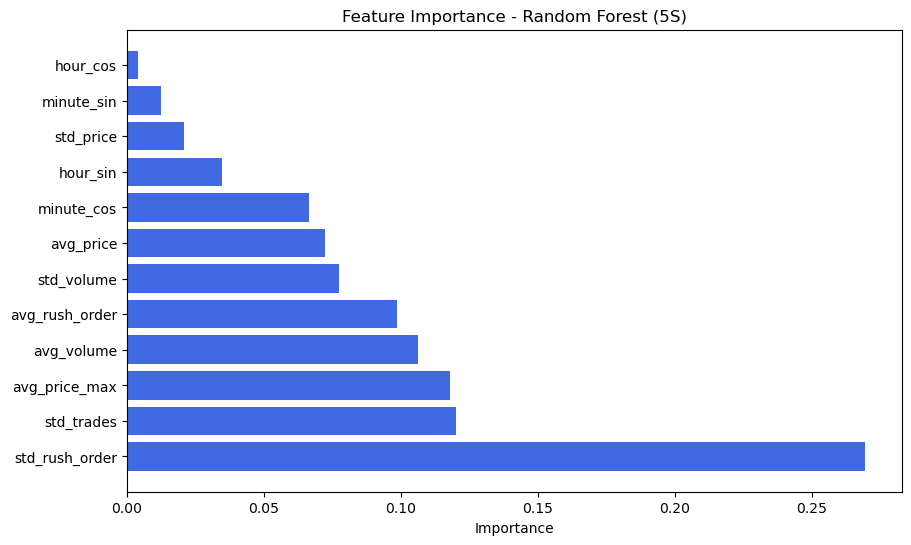

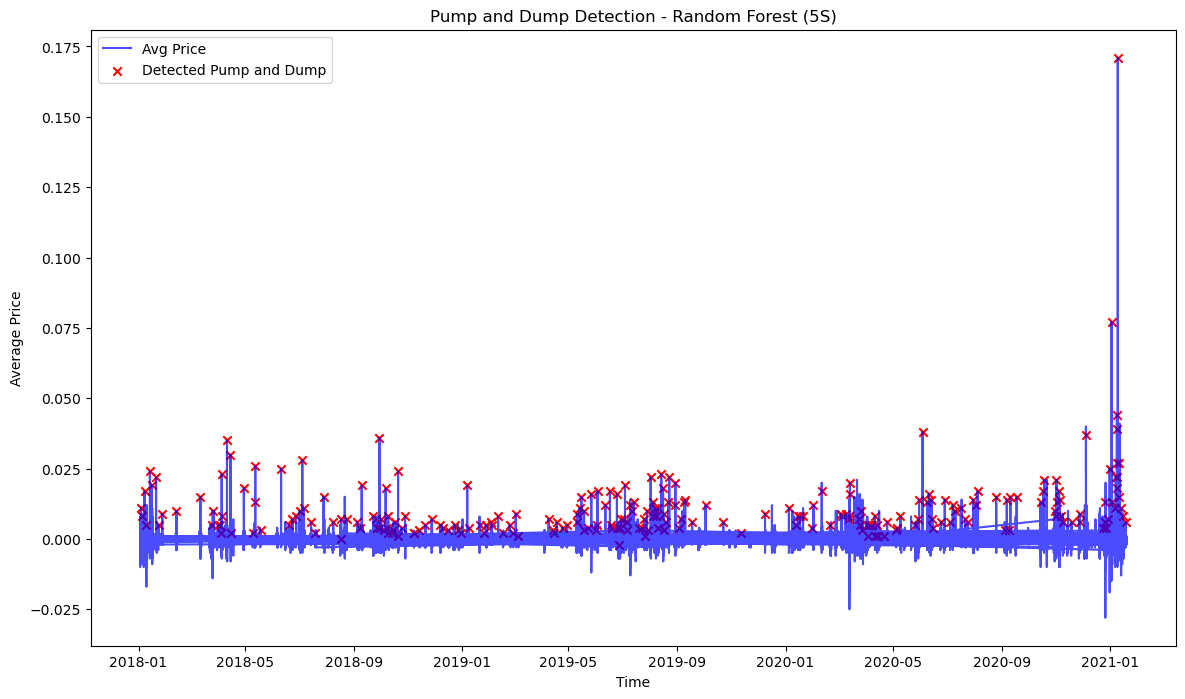

Processing: AdaBoost - 5S
Recall: 0.7949526813880127
Precision: 0.9
F1 score: 0.8442211055276382
ROC-AUC: 0.8974592881111491


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/2606966685.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


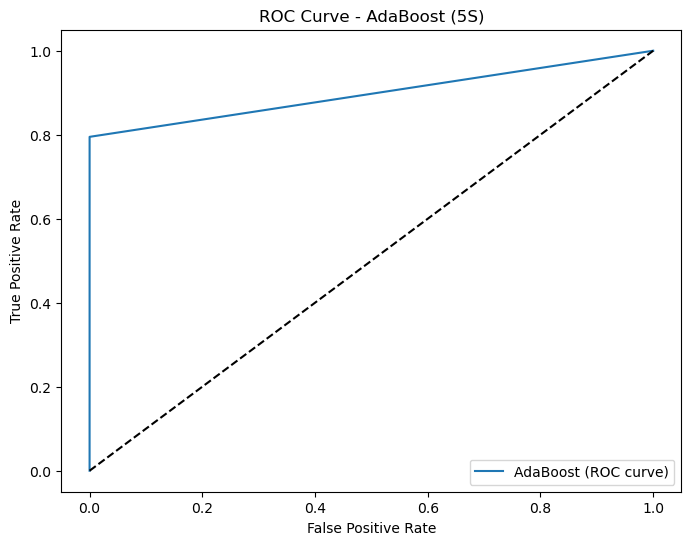

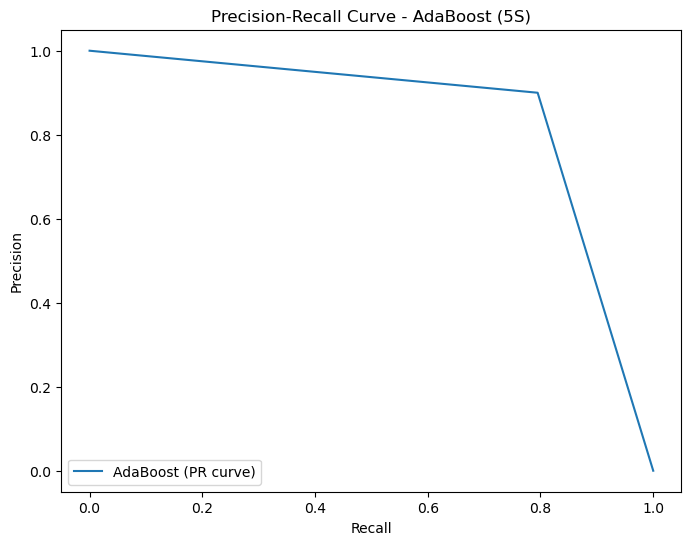

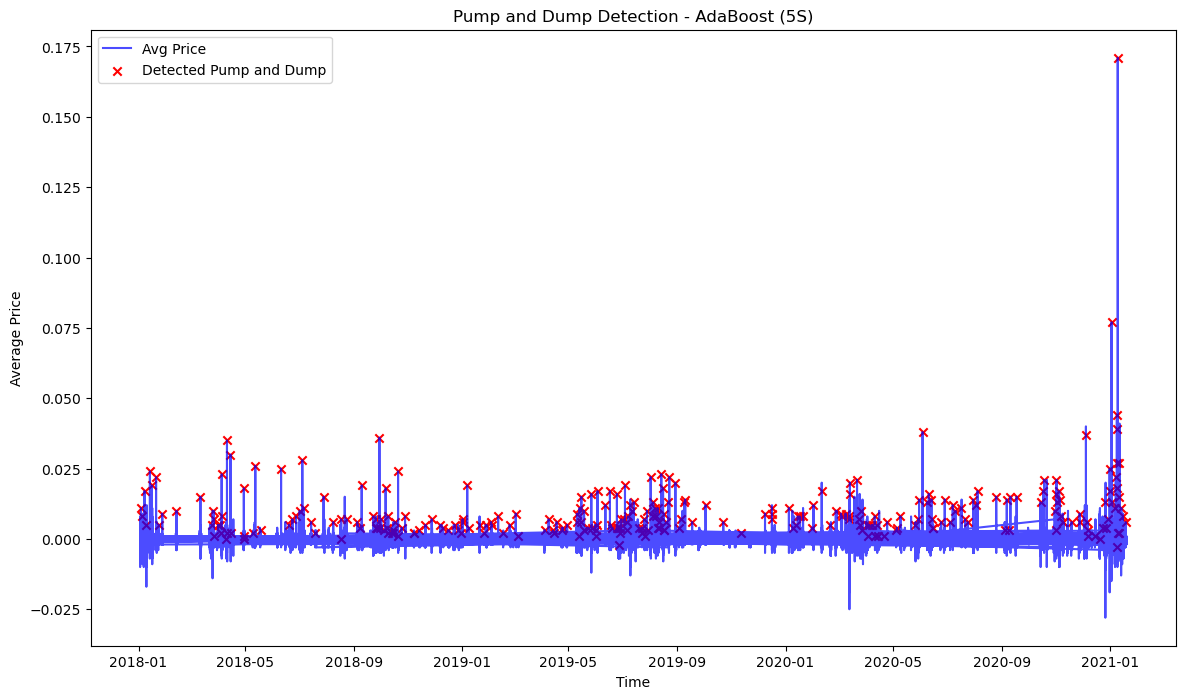

Processing: Gradient Boosting - 5S
Recall: 0.3785488958990536
Precision: 0.4444444444444444
F1 score: 0.4088586030664395
ROC-AUC: 0.689183094827077


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/2606966685.py:47: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


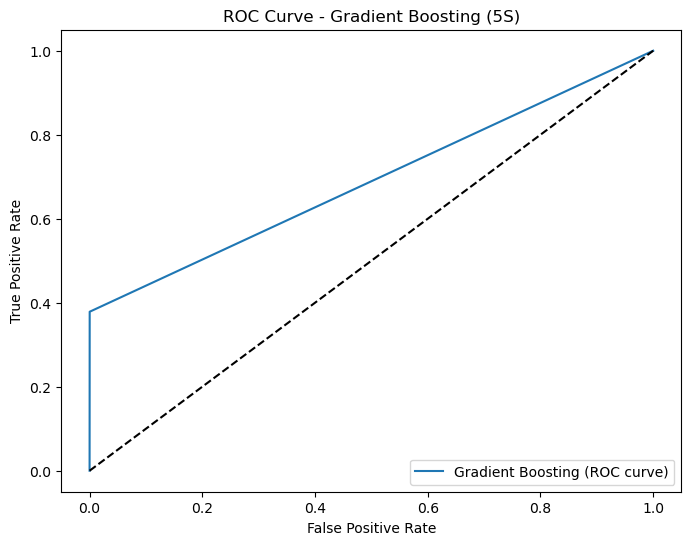

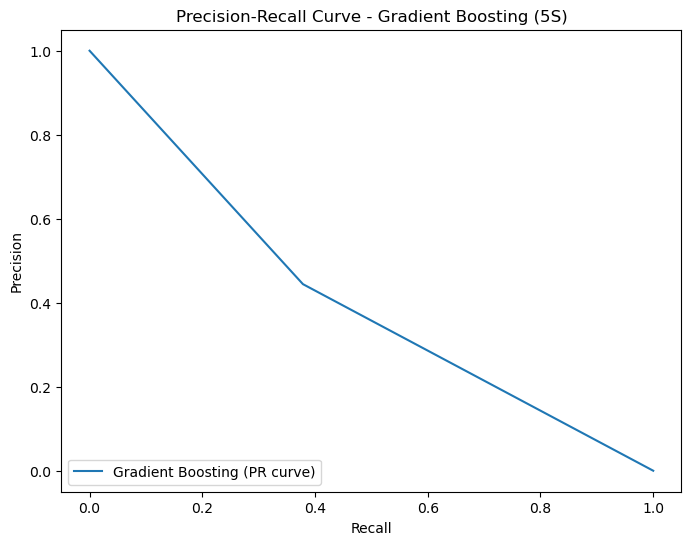

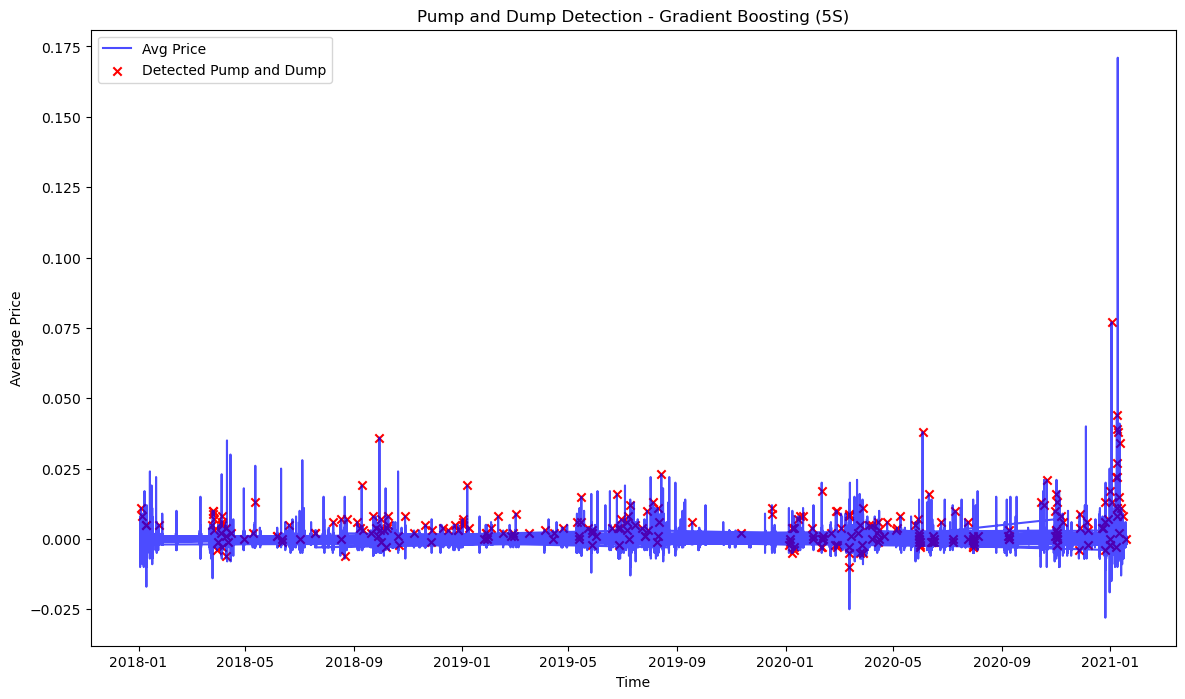

Processing: XGBoost - 5S


/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:09:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:09:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:09:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jakelukasik/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:09:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warni

Recall: 0.7539432176656151
Precision: 0.739938080495356
F1 score: 0.7468750000000001
ROC-AUC: 0.8769204510842358


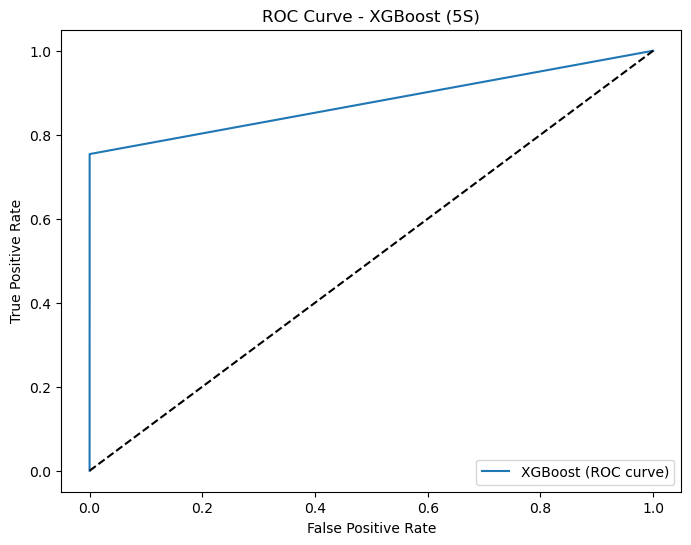

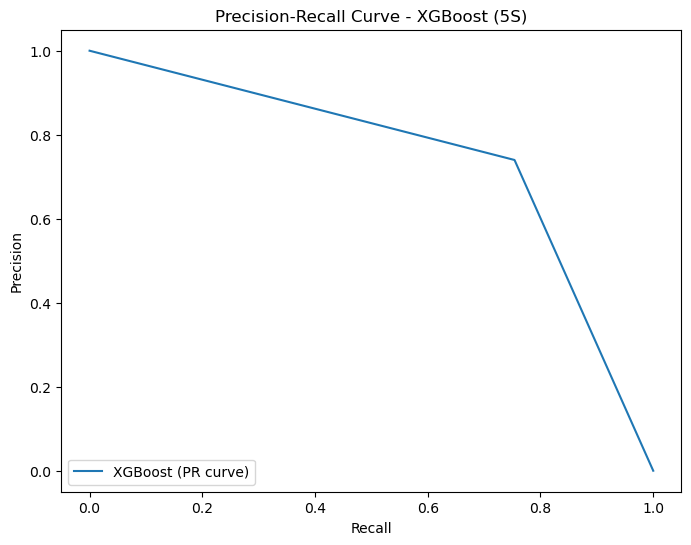

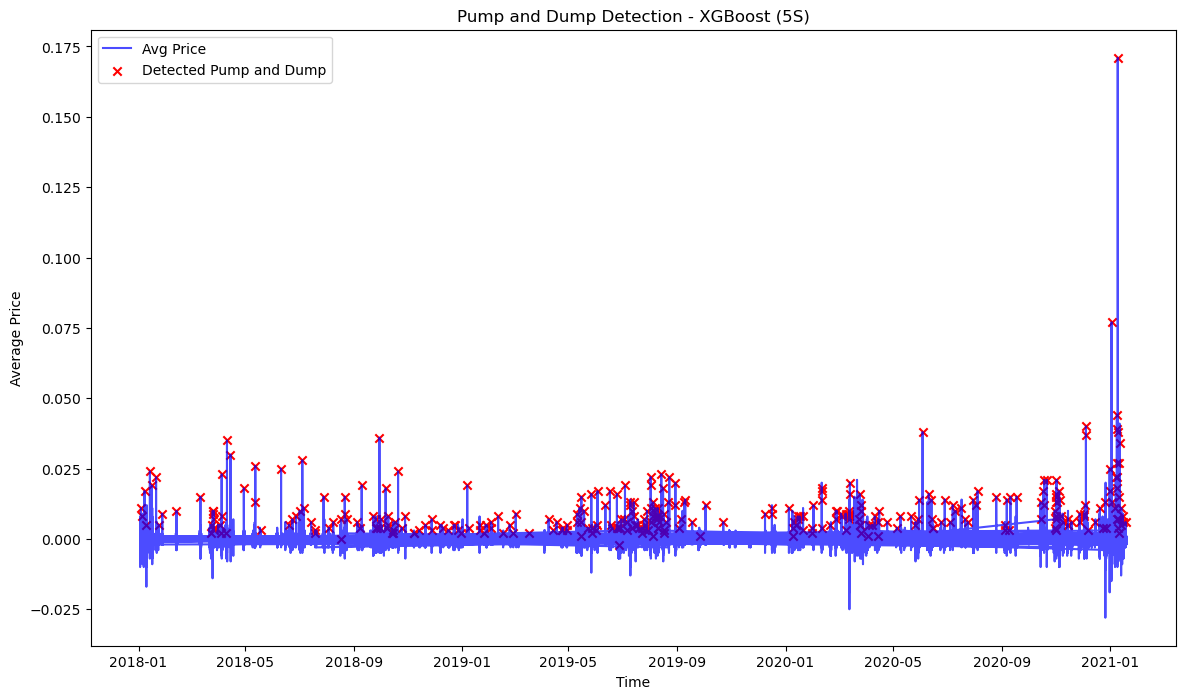

In [45]:
results_df = classifier(time_freq='5S', results_df=results_df)

In [46]:
print(f"Total Execution Time: {datetime.datetime.now() - start}")

# Print the results table
print("\nResults Table:")
print(results_df)

Total Execution Time: 0:21:45.685625

Results Table:
                Model Time Frequency    Recall  Precision  F1 Score   ROC-AUC
0       Random Forest            25S  0.889590   0.965753  0.926108  0.944785
1            AdaBoost            25S  0.908517   0.929032  0.918660  0.954236
2   Gradient Boosting            25S  0.709779   0.868726  0.781250  0.854854
3             XGBoost            25S  0.870662   0.876190  0.873418  0.935291
4       Random Forest            15S  0.854890   0.967857  0.907873  0.927437
5            AdaBoost            15S  0.880126   0.920792  0.900000  0.940043
6   Gradient Boosting            15S  0.252366   0.325203  0.284192  0.626041
7             XGBoost            15S  0.839117   0.818462  0.828660  0.919508
8       Random Forest             5S  0.735016   0.947154  0.827709  0.867500
9            AdaBoost             5S  0.794953   0.900000  0.844221  0.897459
10  Gradient Boosting             5S  0.378549   0.444444  0.408859  0.689183
11         

## **Analysis**

**Best Performing Models by Time Frequency:**

25S:

Best Recall: AdaBoost (0.9085)

Best Precision: Random Forest (0.9658)

Best F1 Score: Random Forest (0.9261)

Best ROC-AUC: AdaBoost (0.9542)

15S:

Best Recall: AdaBoost (0.8801)

Best Precision: Random Forest (0.9679)

Best F1 Score: Random Forest (0.9079)

Best ROC-AUC: AdaBoost (0.9400)

5S:

Best Recall: AdaBoost (0.7949)

Best Precision: Random Forest (0.9472)

Best F1 Score: AdaBoost (0.8442)

Best ROC-AUC: AdaBoost (0.8975)

Since the two best models were overwhelmingly AdaBoost and Random Forest, we now are going to combine them in an ensemble learning method for each time frequency.

In [ ]:
def ensemble_classifier(time_freq, results_df):
    # Load dataset
    computed_data = pd.read_csv(f'/Users/jakelukasik/Desktop/School/Spring 2025/DS 340W/Implementation/PAPER2/features_{time_freq}.csv', parse_dates=['date'])

    # Define feature columns
    features = ['std_rush_order',
                'avg_rush_order',
                'std_trades',
                'std_volume',
                'avg_volume',
                'std_price',
                'avg_price',
                'avg_price_max',
                'hour_sin',
                'hour_cos',
                'minute_sin',
                'minute_cos']

    # Prepare feature and target variables
    X = computed_data[features]
    Y = computed_data['gt'].astype(int).values.ravel()

    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Initialize RandomForest and AdaBoost classifiers that we'll build the ensemble learning method with
    rf_clf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=1)
    ada_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=5), n_estimators=100, learning_rate=0.5, random_state=0)

    # Create an ensemble model using VotingClassifier
    ensemble_clf = VotingClassifier(estimators=[('rf', rf_clf), ('ada', ada_clf)], voting='hard')

    # Cross-validation predictions
    y_pred = cross_val_predict(ensemble_clf, X_scaled, Y.ravel(), cv=StratifiedKFold(n_splits=5), n_jobs=7)

    # Calculate metrics
    recall = recall_score(Y, y_pred)
    precision = precision_score(Y, y_pred)
    f1 = f1_score(Y, y_pred)
    roc_auc = roc_auc_score(Y, y_pred)

    # Store results in DataFrame
    results_df = results_df.append({
        'Model': 'Random Forest + AdaBoost (Ensemble)',
        'Time Frequency': time_freq,
        'Recall': recall,
        'Precision': precision,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    }, ignore_index=True)

    # Print evaluation metrics
    print(f'Recall: {recall}')
    print(f'Precision: {precision}')
    print(f'F1 score: {f1}')
    print(f'ROC-AUC: {roc_auc}')

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(Y, y_pred)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label='Ensemble (ROC curve)')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - Random Forest + AdaBoost Ensemble ({time_freq})')
    plt.legend(loc="lower right")
    plt.show()

    # Precision-Recall curve
    precision_vals, recall_vals, _ = precision_recall_curve(Y, y_pred)
    plt.figure(figsize=(8, 6))
    plt.plot(recall_vals, precision_vals, label='Ensemble (PR curve)')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - Random Forest + AdaBoost Ensemble ({time_freq})')
    plt.legend(loc="lower left")
    plt.show()

    # Add predictions to computed data
    computed_data['predicted_gt'] = y_pred
    detected_pump_dump = computed_data[computed_data['predicted_gt'] == 1]
    
    # Plot detected pump and dump events
    if not detected_pump_dump.empty:
        plt.figure(figsize=(14, 8))
        plt.plot(computed_data['date'], computed_data['avg_price'], label='Avg Price', color='blue', alpha=0.7)
        plt.scatter(detected_pump_dump['date'], detected_pump_dump['avg_price'], color='red', label='Detected Pump and Dump', marker='x')
        plt.title(f'Pump and Dump Detection - Random Forest + AdaBoost Ensemble ({time_freq})')
        plt.xlabel('Time')
        plt.ylabel('Average Price')
        plt.legend(loc="upper left")
        plt.show()

    return results_df

Recall: 0.8801261829652997
Precision: 0.9721254355400697
F1 score: 0.923841059602649
ROC-AUC: 0.9400547899717747


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/3600701758.py:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


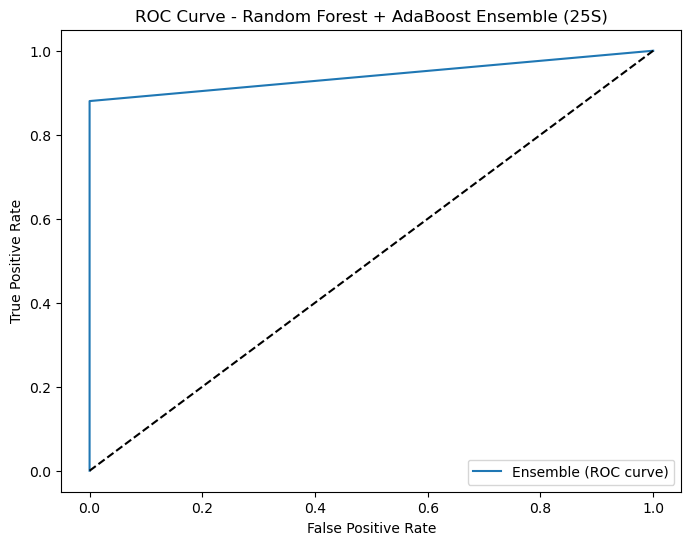

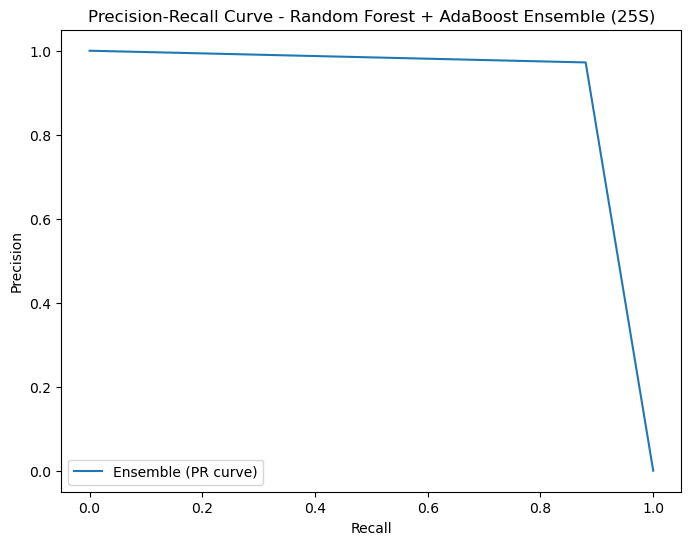

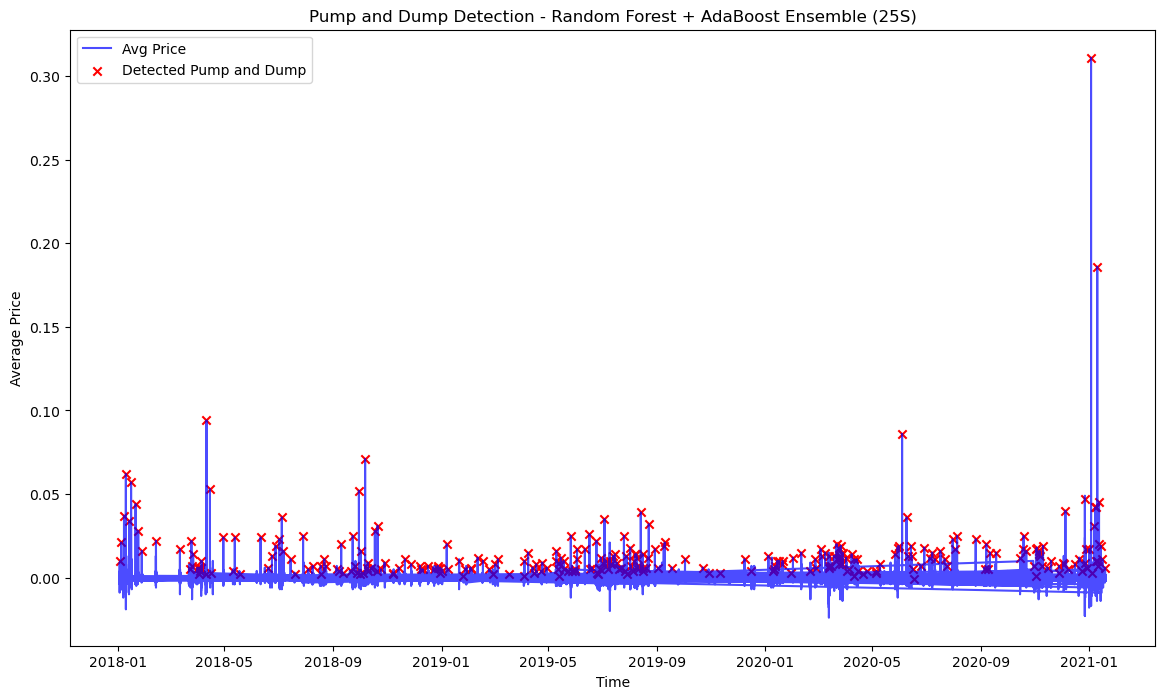

In [48]:
ensemble_results_df = pd.DataFrame(columns=['Model', 'Time Frequency', 'Recall', 'Precision', 'F1 Score', 'ROC-AUC'])

start = datetime.datetime.now()
ensemble_results_df = ensemble_classifier(time_freq='25S', results_df=ensemble_results_df)

Recall: 0.8422712933753943
Precision: 0.9709090909090909
F1 score: 0.9020270270270271
ROC-AUC: 0.9211287948735938


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/3600701758.py:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


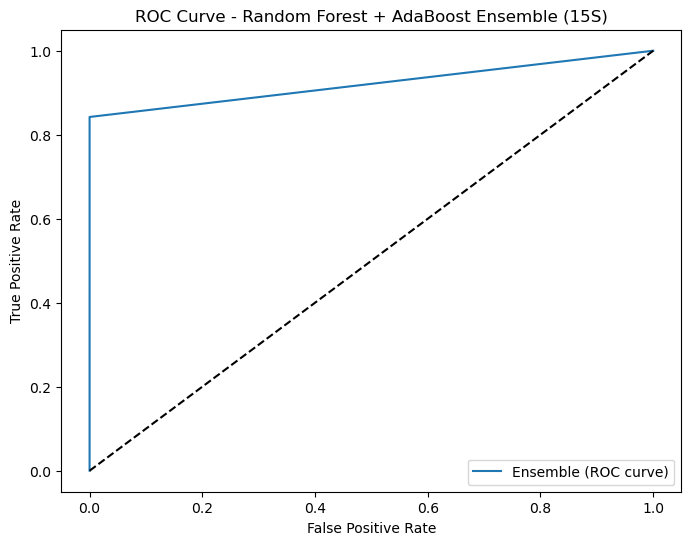

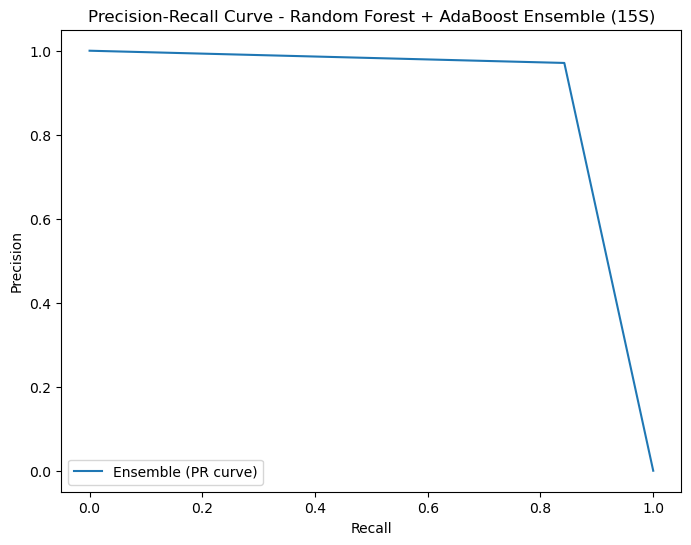

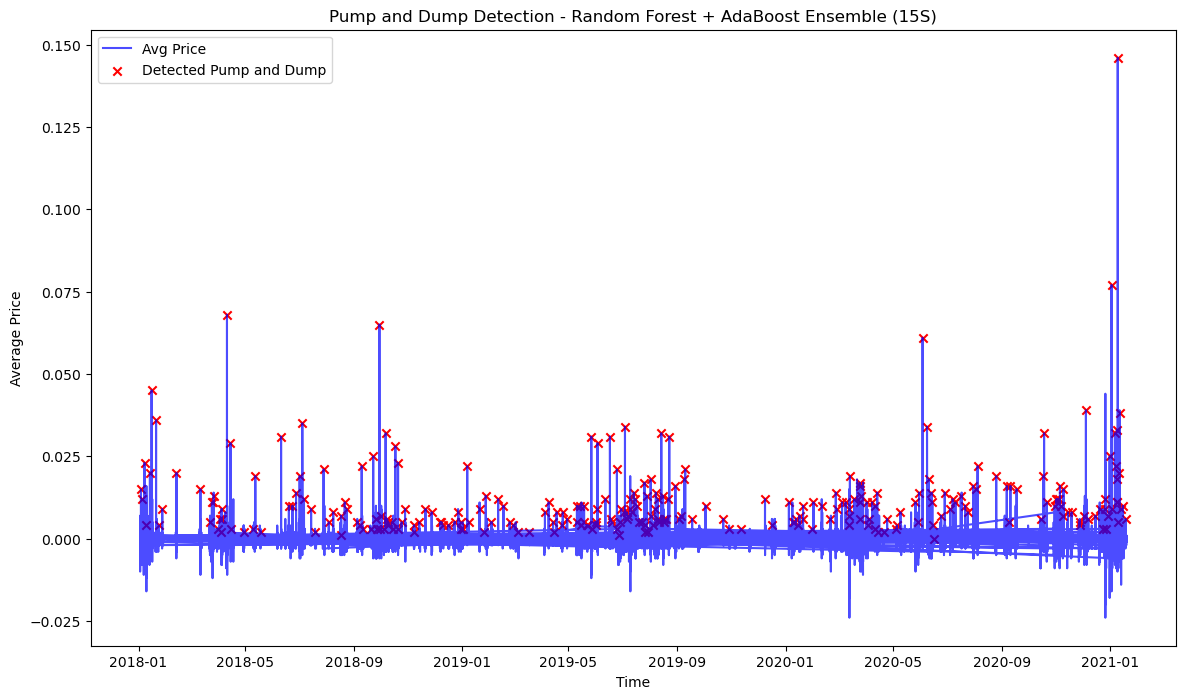

In [49]:
ensemble_results_df = ensemble_classifier(time_freq='15S', results_df=ensemble_results_df)

/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_18373/3600701758.py:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


Recall: 0.7287066246056783
Precision: 0.9625
F1 score: 0.829443447037702
ROC-AUC: 0.8643478311154921


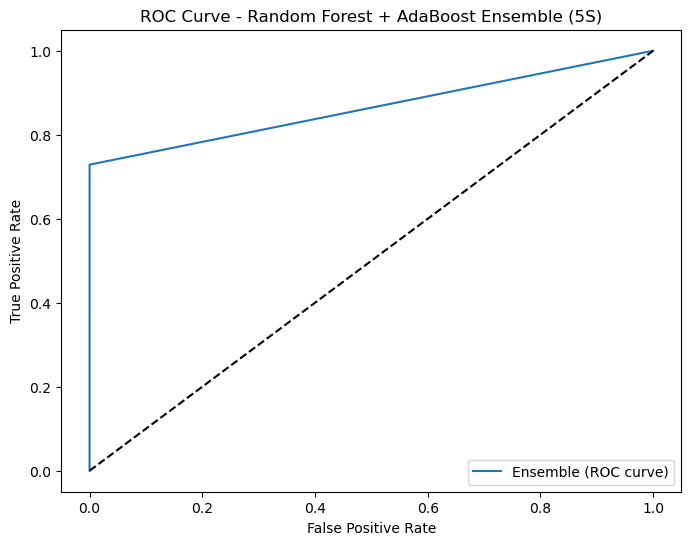

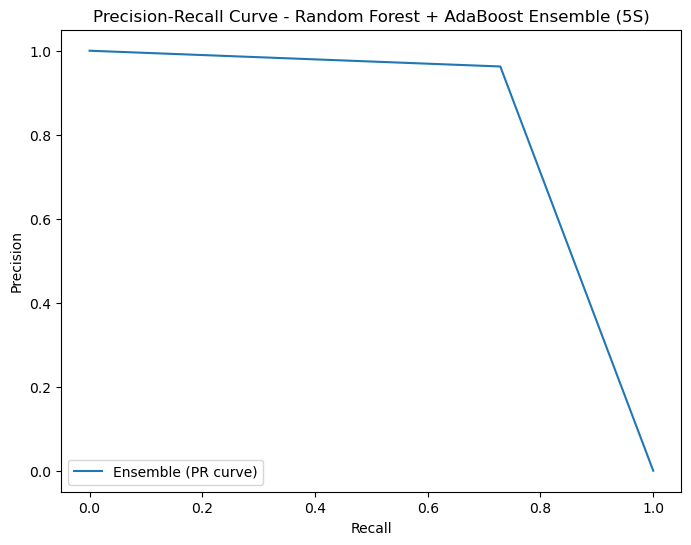

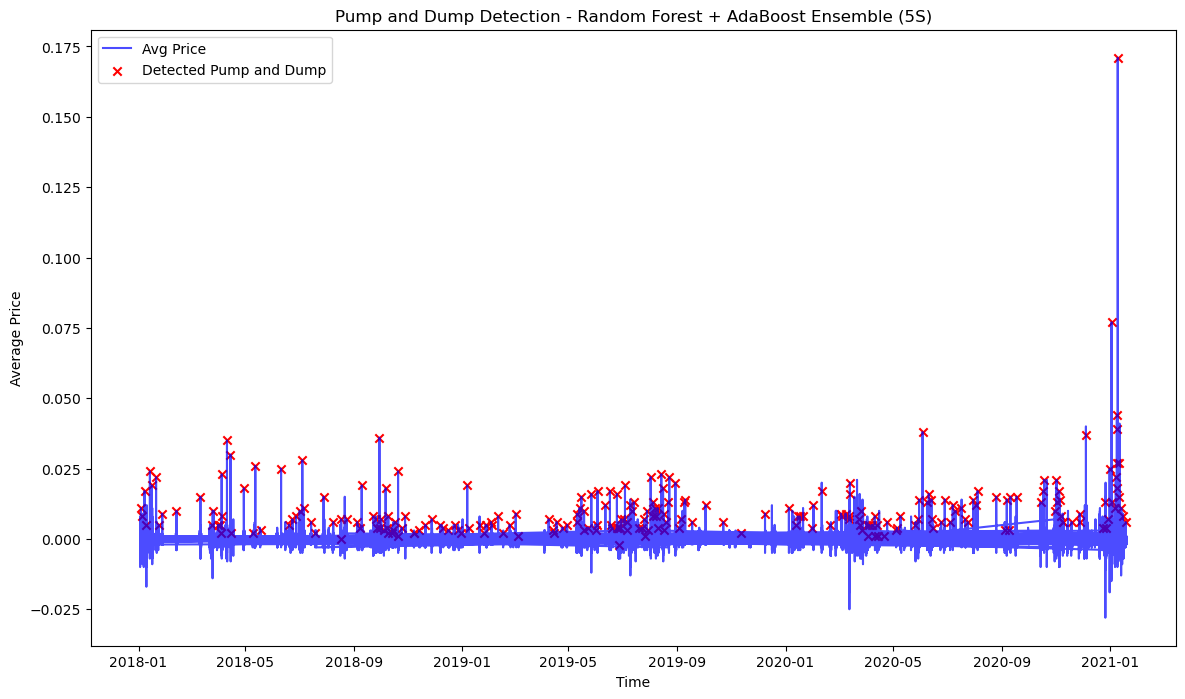

In [50]:
ensemble_results_df = ensemble_classifier(time_freq='5S', results_df=ensemble_results_df)

In [51]:
print(f"Total Execution Time: {datetime.datetime.now() - start}")

# Print the results table
print("\nEnsemble Method Results Table:")
print(ensemble_results_df)

Total Execution Time: 0:14:15.294351

Ensemble Method Results Table:
                                 Model Time Frequency    Recall  Precision  \
0  Random Forest + AdaBoost (Ensemble)            25S  0.880126   0.972125   
1  Random Forest + AdaBoost (Ensemble)            15S  0.842271   0.970909   
2  Random Forest + AdaBoost (Ensemble)             5S  0.728707   0.962500   

   F1 Score   ROC-AUC  
0  0.923841  0.940055  
1  0.902027  0.921129  
2  0.829443  0.864348  


Now, let us go ahead and try a new type of detection algorithm. For this, we are going to turn the scope to inspect how an anomaly detection algorithm works on our dataset. We will follow the same methodology from before, testing with 25S, 15S, and 5S time intervals. We will also define a similar function to the ones we built before to run an isolation forest model on our datasets:

In [9]:
def isolation_forest_detector(time_freq, results_df, contamination=0.01):
    computed_data = pd.read_csv(f'/Users/jakelukasik/Desktop/School/Spring 2025/DS 340W/Implementation/PAPER2/features_{time_freq}.csv', parse_dates=['date'])

    features = ['std_rush_order',
                'avg_rush_order',
                'std_trades',
                'std_volume',
                'avg_volume',
                'std_price',
                'avg_price',
                'avg_price_max',
                'hour_sin',
                'hour_cos',
                'minute_sin',
                'minute_cos']

    X = computed_data[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = IsolationForest(n_estimators=200, contamination=contamination, random_state=42)
    computed_data['anomaly_score'] = model.fit_predict(X_scaled)
    computed_data['anomaly'] = computed_data['anomaly_score'].apply(lambda x: 1 if x == -1 else 0)

    detected_anomalies = computed_data[computed_data['anomaly'] == 1]

    # If ground truth exists, evaluate
    if 'gt' in computed_data.columns:
        Y_true = computed_data['gt'].astype(int)
        Y_pred = computed_data['anomaly']

        precision = precision_score(Y_true, Y_pred)
        recall = recall_score(Y_true, Y_pred)
        f1 = f1_score(Y_true, Y_pred)

        results_df = results_df.append({
            'Model': 'Isolation Forest',
            'Time Frequency': time_freq,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'Contamination': contamination  # ROC-AUC not meaningful in unsupervised here
        }, ignore_index=True)

        print(f'Precision: {precision:.4f}')
        print(f'Recall: {recall:.4f}')
        print(f'F1 Score: {f1:.4f}')
    """
    # Plot detected anomalies over price
    plt.figure(figsize=(14, 8))
    plt.plot(computed_data['date'], computed_data['avg_price'], label='Avg Price', color='blue', alpha=0.7)
    plt.scatter(detected_anomalies['date'], detected_anomalies['avg_price'], color='red', label='Detected Anomalies', marker='x')
    plt.title(f'Anomaly Detection - Isolation Forest ({time_freq})')
    plt.xlabel('Time')
    plt.ylabel('Average Price')
    plt.legend(loc='upper left')
    plt.show()
    """
    if 'gt' in computed_data.columns:
        anomalies_with_gt = computed_data[computed_data['anomaly'] == 1].copy()
        anomalies_with_gt['is_true_positive'] = anomalies_with_gt['gt'] == 1

        true_positives = anomalies_with_gt[anomalies_with_gt['is_true_positive']]
        false_positives = anomalies_with_gt[~anomalies_with_gt['is_true_positive']]
    else:
        true_positives = pd.DataFrame()
        false_positives = computed_data[computed_data['anomaly'] == 1]

    # Plot average price with anomalies
    plt.figure(figsize=(14, 8))
    plt.plot(computed_data['date'], computed_data['avg_price'], label='Avg Price', color='blue', alpha=0.7)

    # Plot anomalies: green for correct, red for incorrect
    if not true_positives.empty:
        plt.scatter(true_positives['date'], true_positives['avg_price'], color='green', label='True Positive', marker='x')
    if not false_positives.empty:
        plt.scatter(false_positives['date'], false_positives['avg_price'], color='red', label='False Positive', marker='x')

    plt.title(f'Anomaly Detection - Isolation Forest ({time_freq})')
    plt.xlabel('Time')
    plt.ylabel('Average Price')
    plt.legend(loc='upper left')
    plt.show()

    return results_df

5e-05
Precision: 1.0000
Recall: 0.0757
F1 Score: 0.1408


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


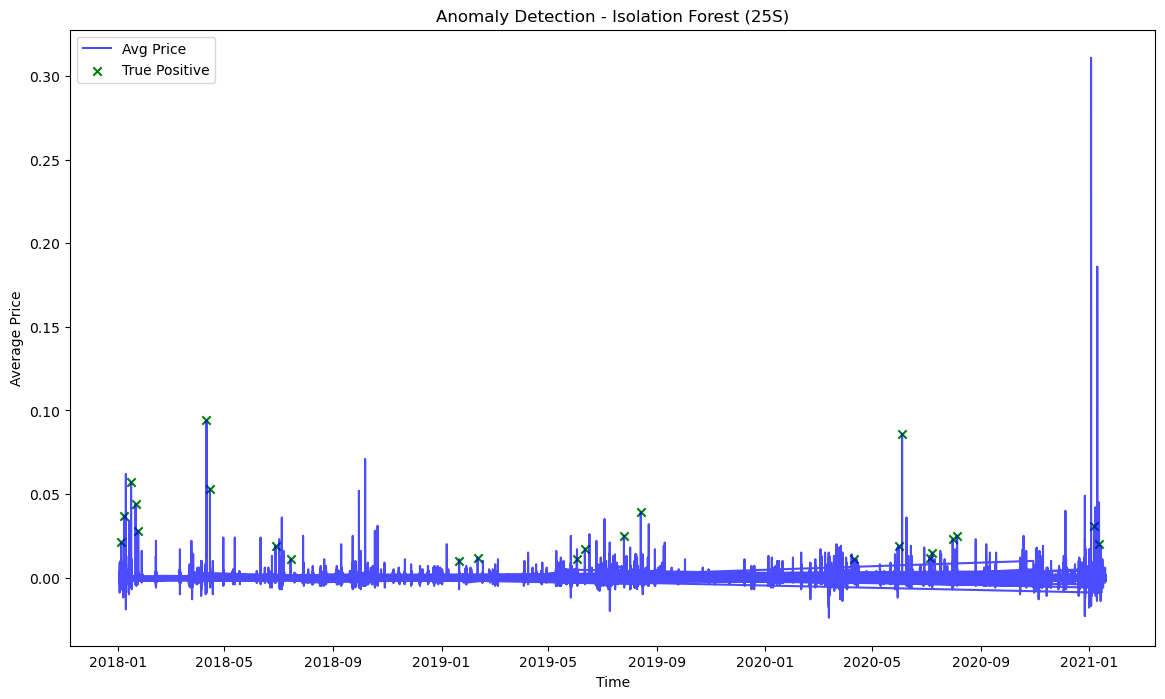

0.0001
Precision: 1.0000
Recall: 0.1483
F1 Score: 0.2582


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


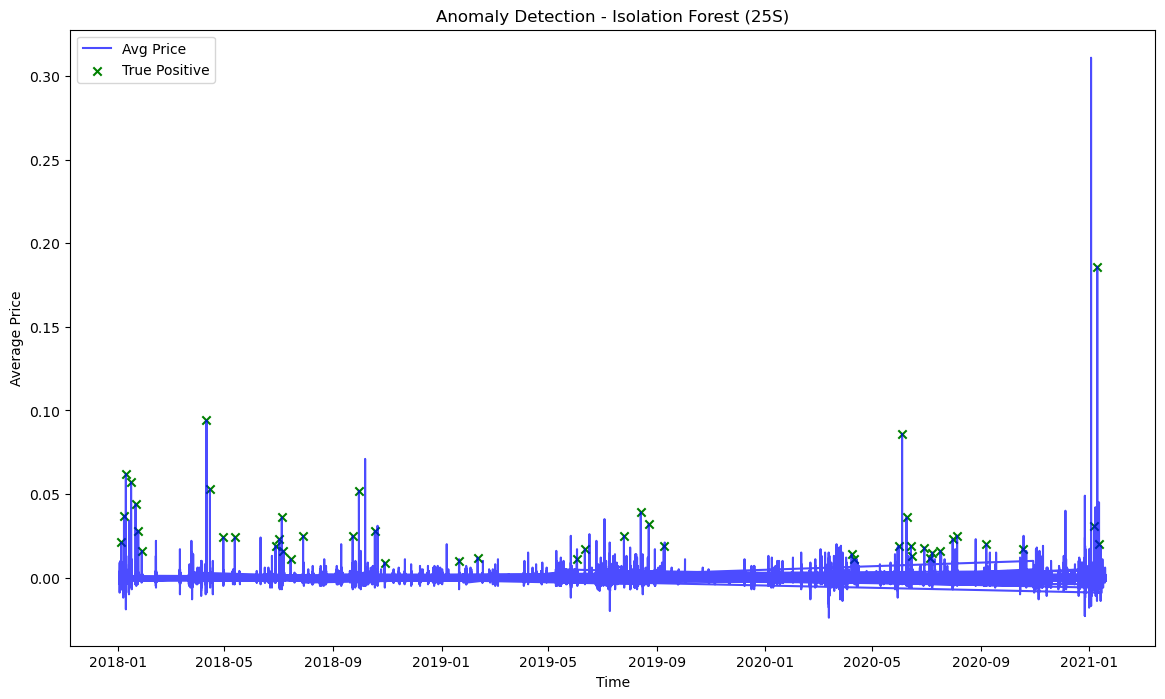

0.0002
Precision: 0.9792
Recall: 0.2965
F1 Score: 0.4552


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


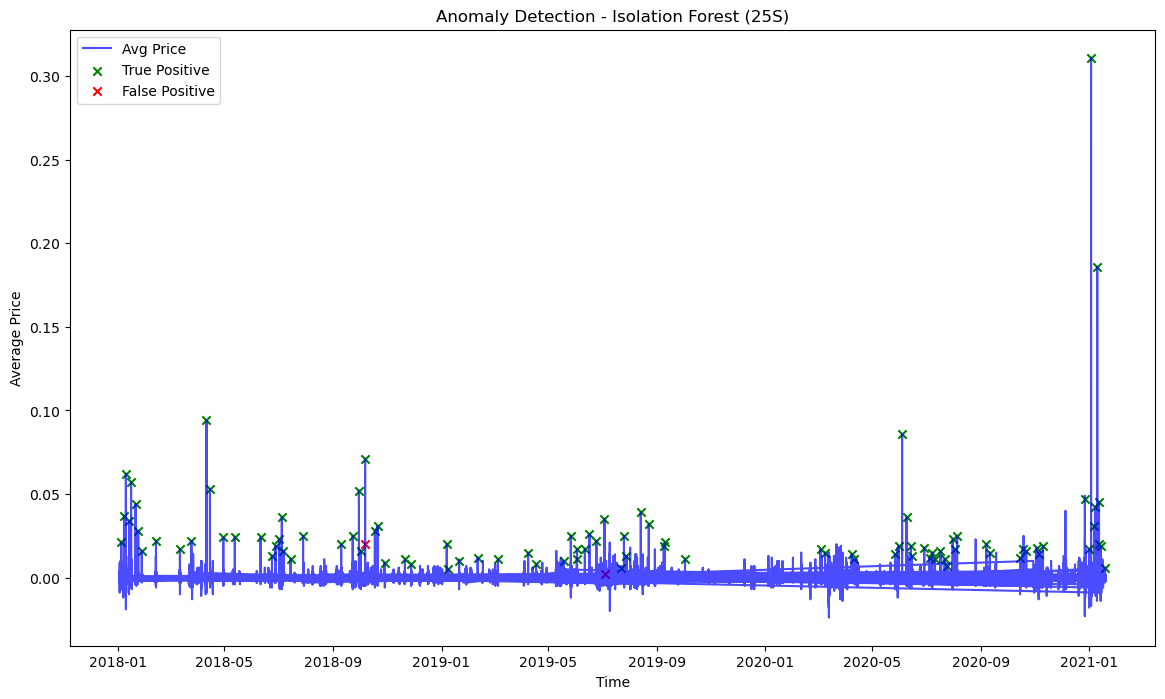

0.0003
Precision: 0.8207
Recall: 0.3754
F1 Score: 0.5152


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


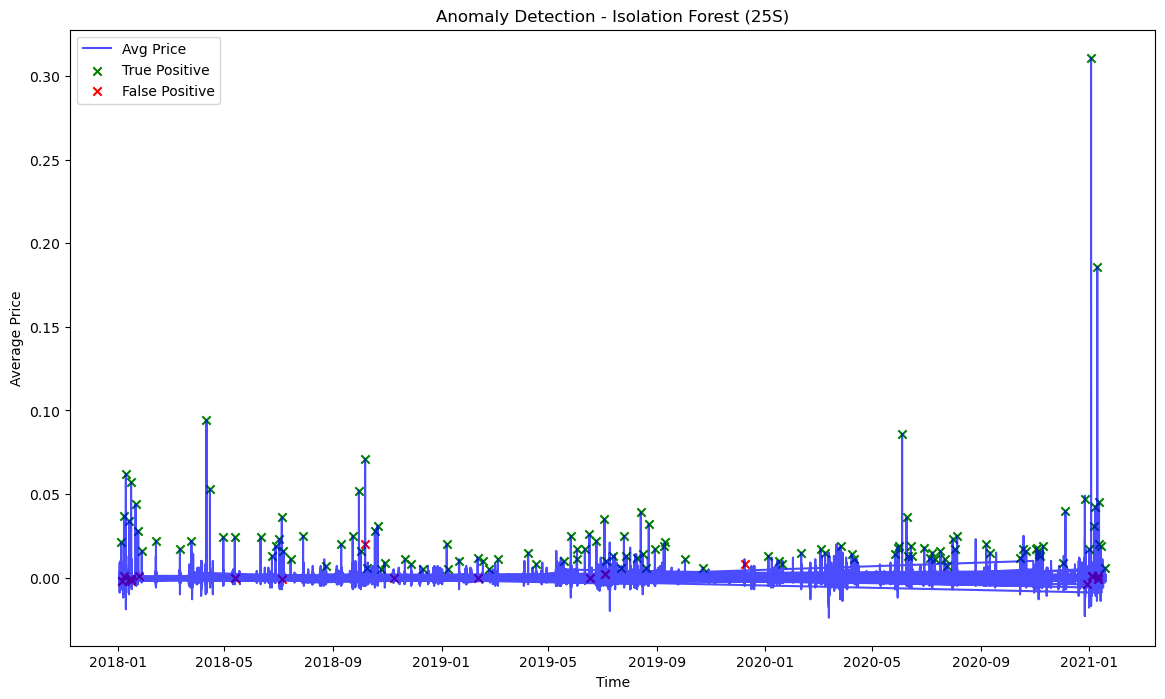

0.0005
Precision: 0.6116
Recall: 0.4669
F1 Score: 0.5295


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


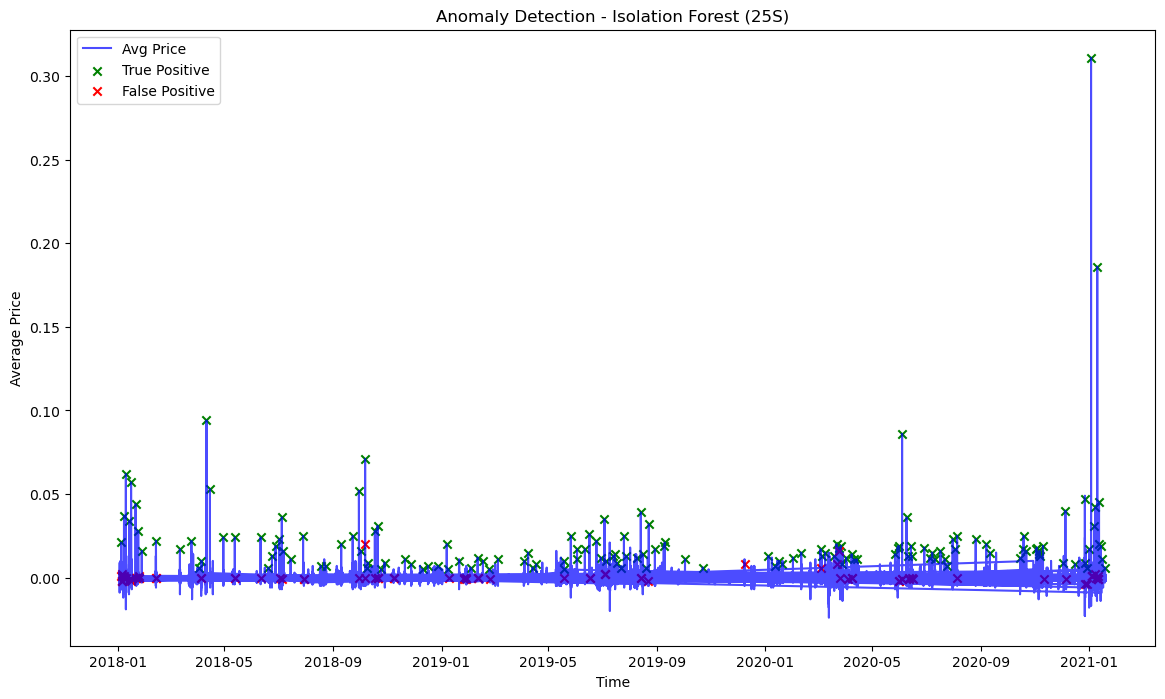

0.001
Precision: 0.4244
Recall: 0.6467
F1 Score: 0.5125


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


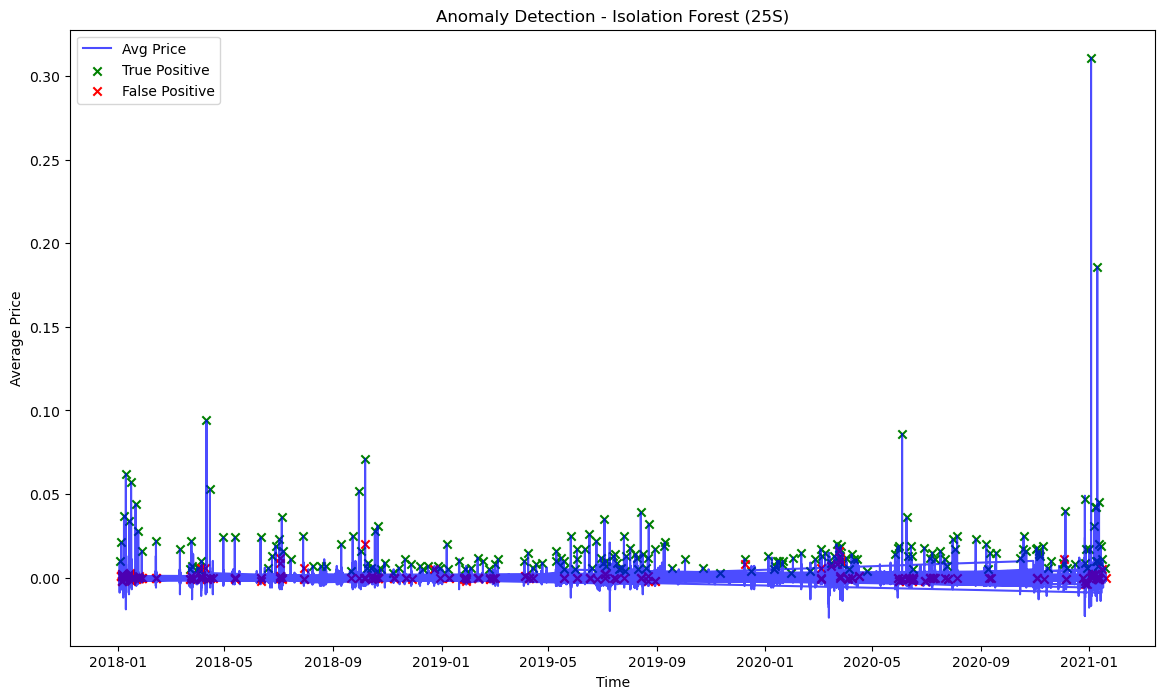

In [10]:
anom_detx_df = pd.DataFrame(columns=['Model', 'Time Frequency', 'Recall', 'Precision', 'F1 Score', 'Contamination'])

start = datetime.datetime.now()
for contamination in [0.00005, 0.0001, 0.0002, 0.0003, 0.0005, 0.001]:
    print(contamination)
    anom_detx_df = isolation_forest_detector(time_freq='25S', results_df=anom_detx_df, contamination=contamination)
# anom_detx_df = isolation_forest_detector(time_freq='25S', results_df=anom_detx_df, contamination=0.01)

Precision: 0.4000
Recall: 0.0379
F1 Score: 0.0692


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


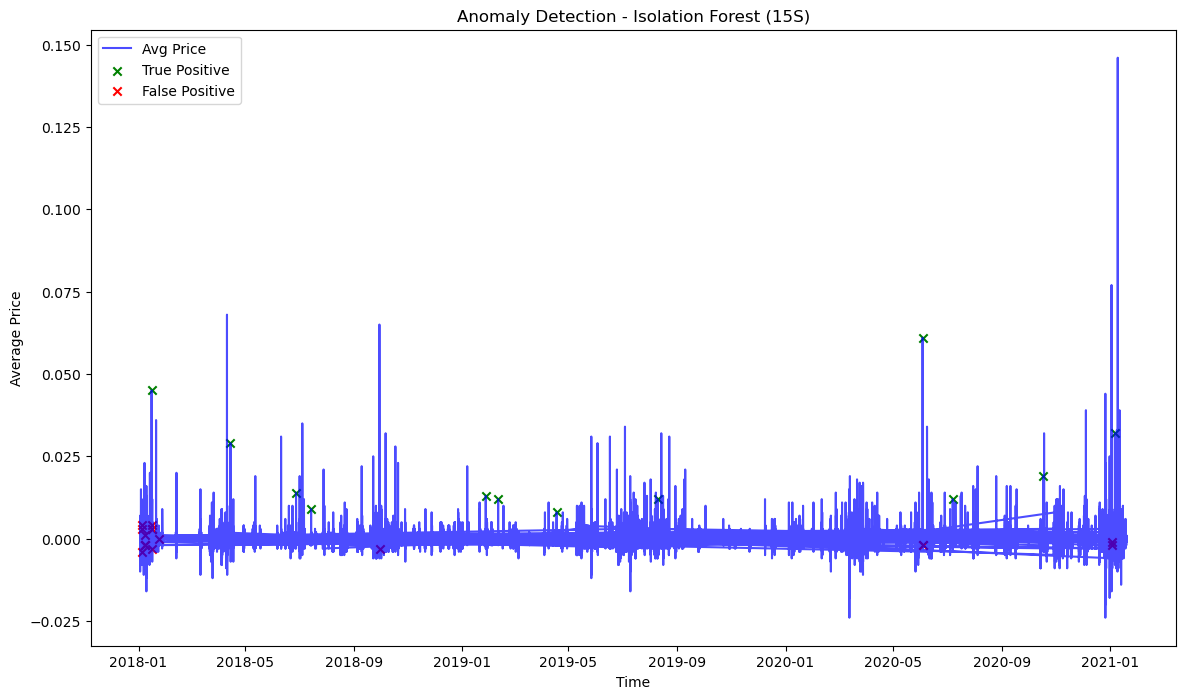

Precision: 0.5254
Recall: 0.0978
F1 Score: 0.1649


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


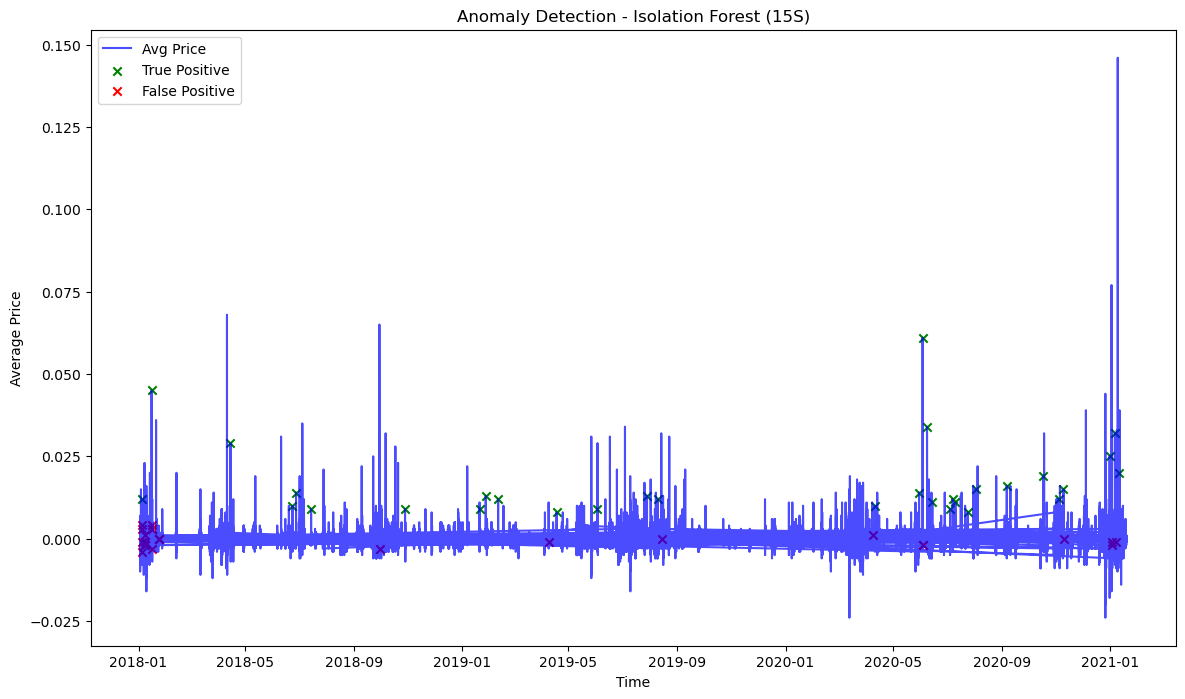

/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


Precision: 0.5135
Recall: 0.1798
F1 Score: 0.2664


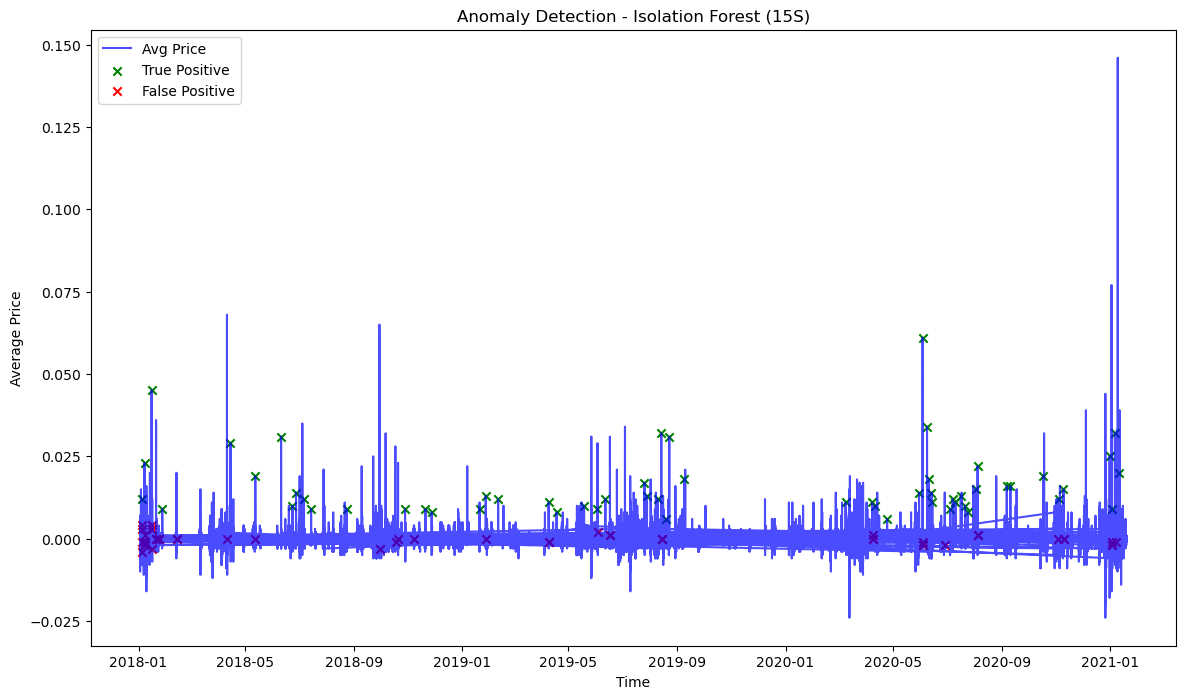

Precision: 0.5057
Recall: 0.2808
F1 Score: 0.3611


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


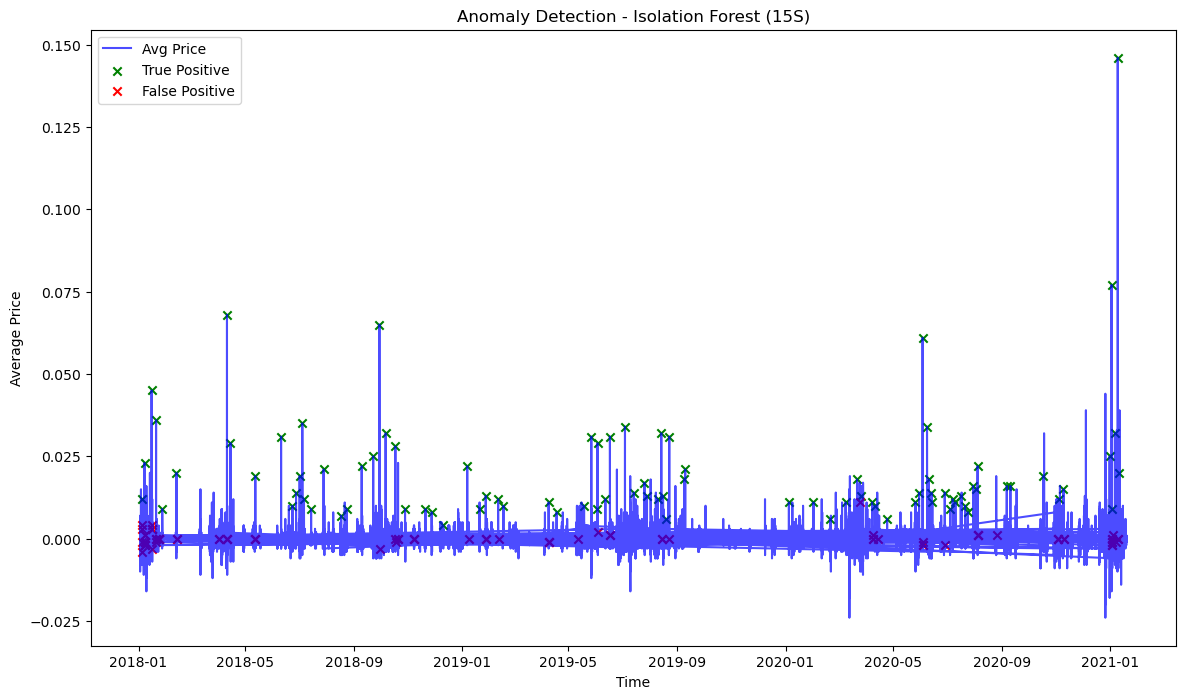

Precision: 0.4198
Recall: 0.3880
F1 Score: 0.4033


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


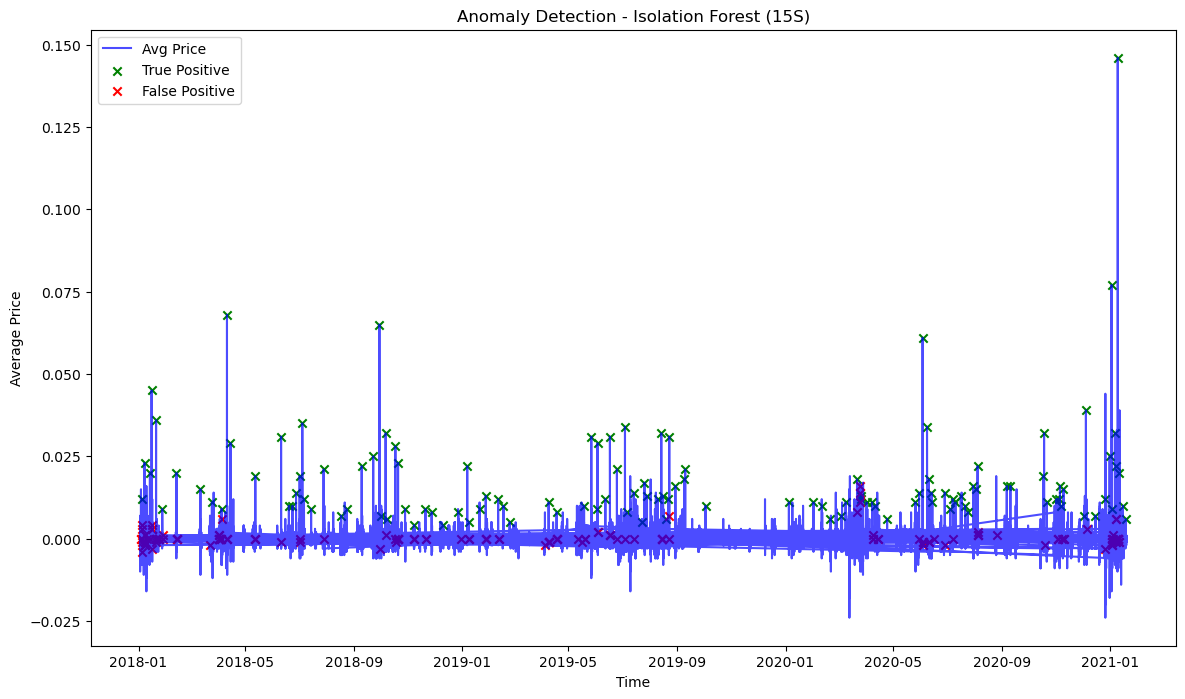

Precision: 0.3026
Recall: 0.5584
F1 Score: 0.3925


/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


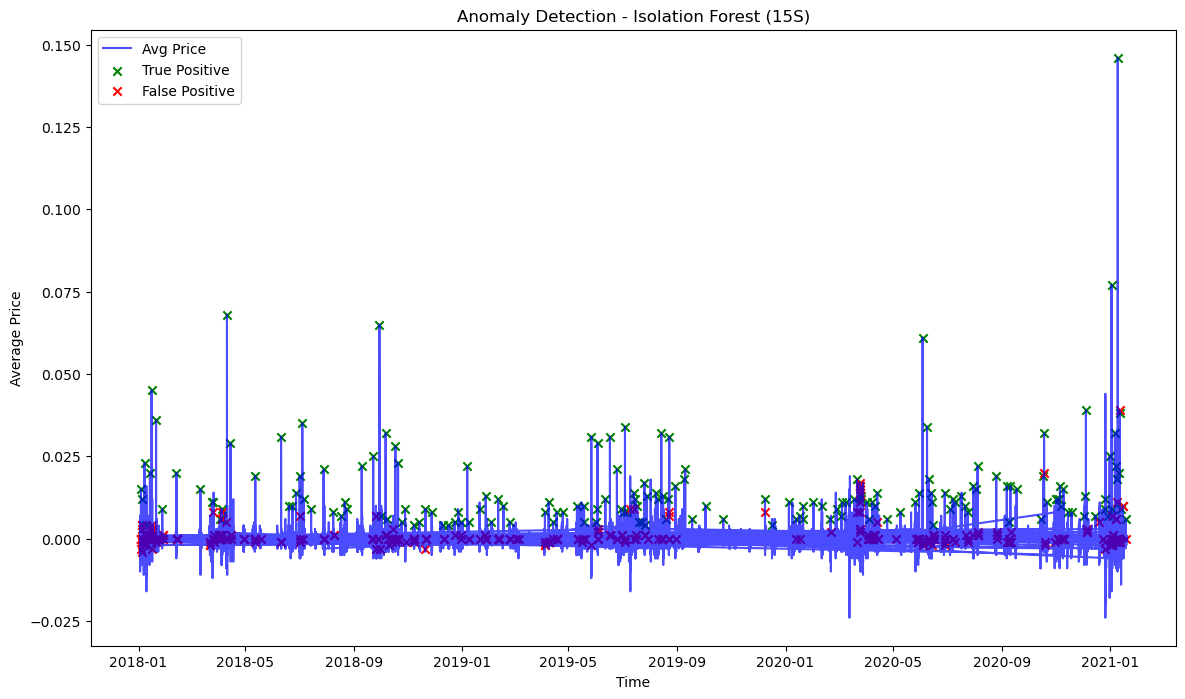

In [11]:
for contamination in [0.00005, 0.0001, 0.0002, 0.0003, 0.0005, 0.001]:
    anom_detx_df = isolation_forest_detector(time_freq='15S', results_df=anom_detx_df, contamination=contamination)

/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


Precision: 0.8571
Recall: 0.1136
F1 Score: 0.2006


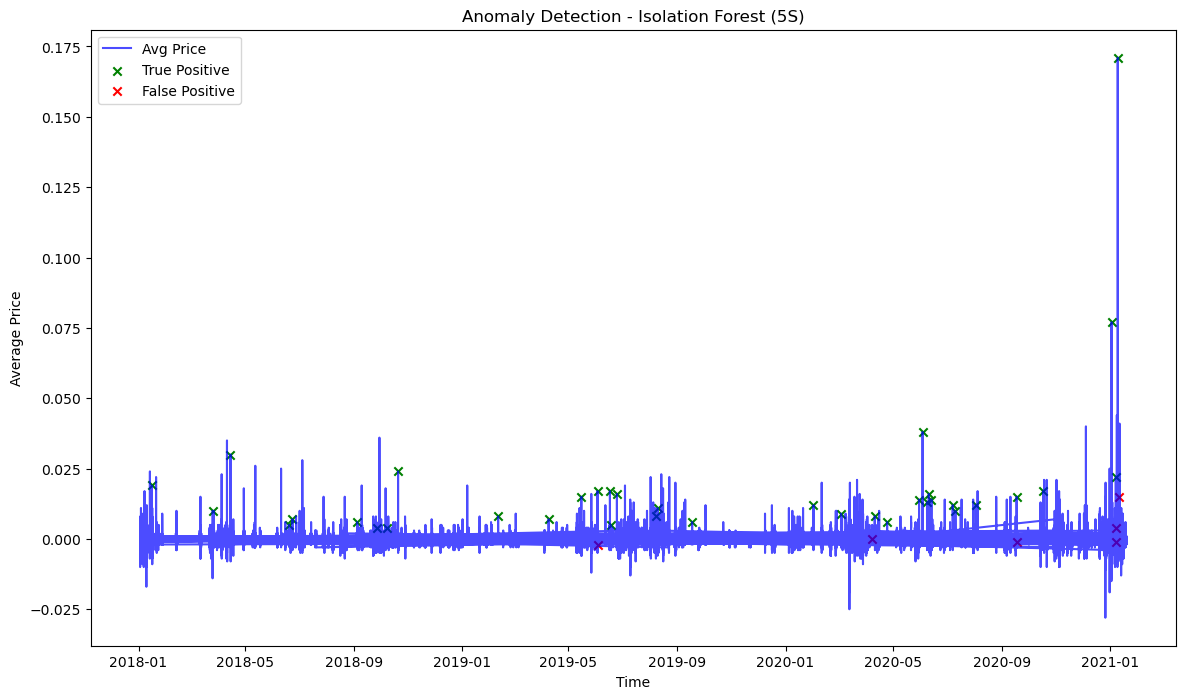

/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


Precision: 0.8313
Recall: 0.2177
F1 Score: 0.3450


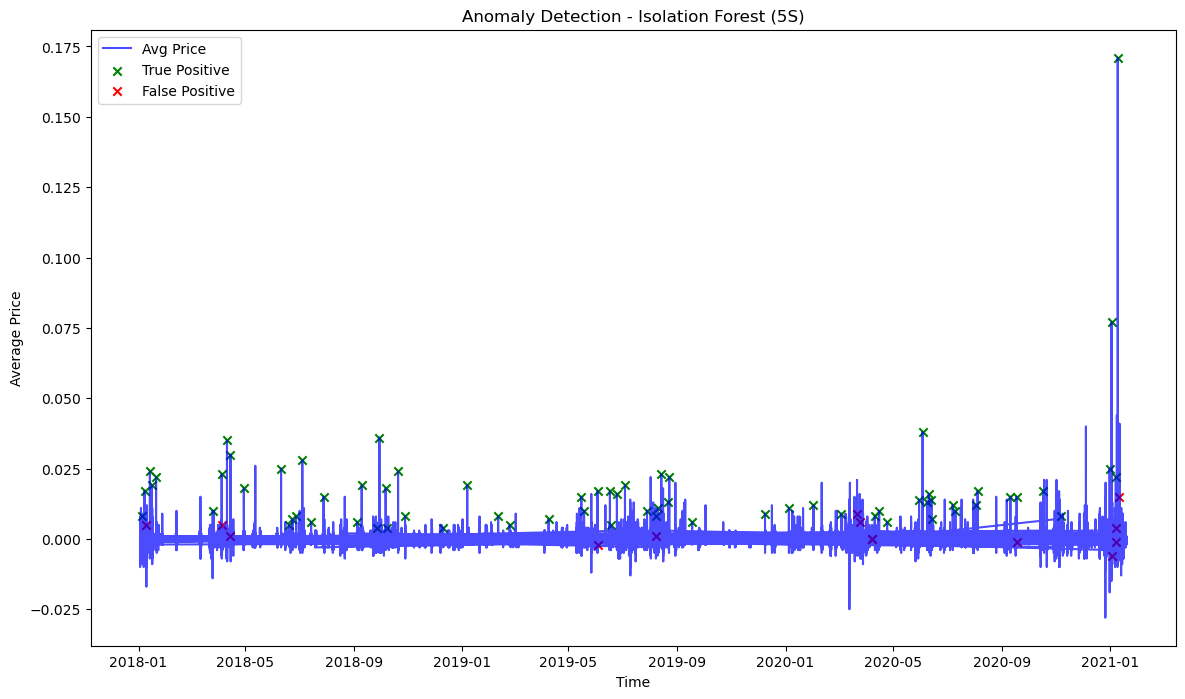

/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


Precision: 0.6970
Recall: 0.3628
F1 Score: 0.4772


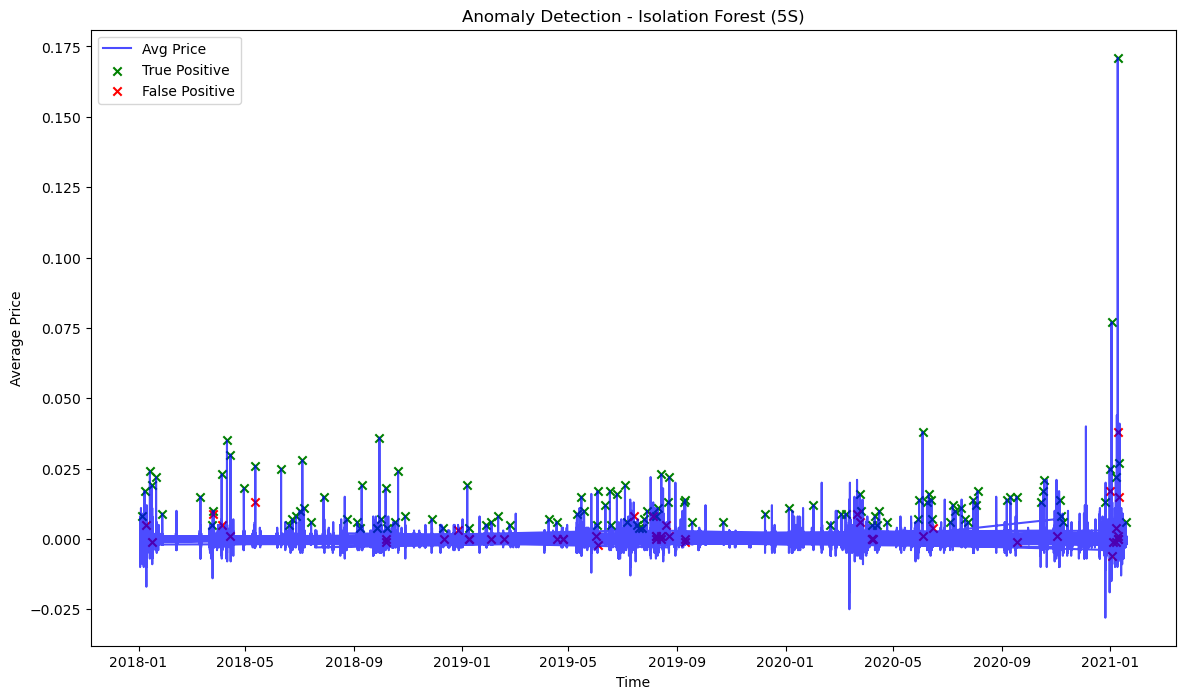

/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


Precision: 0.5668
Recall: 0.4416
F1 Score: 0.4965


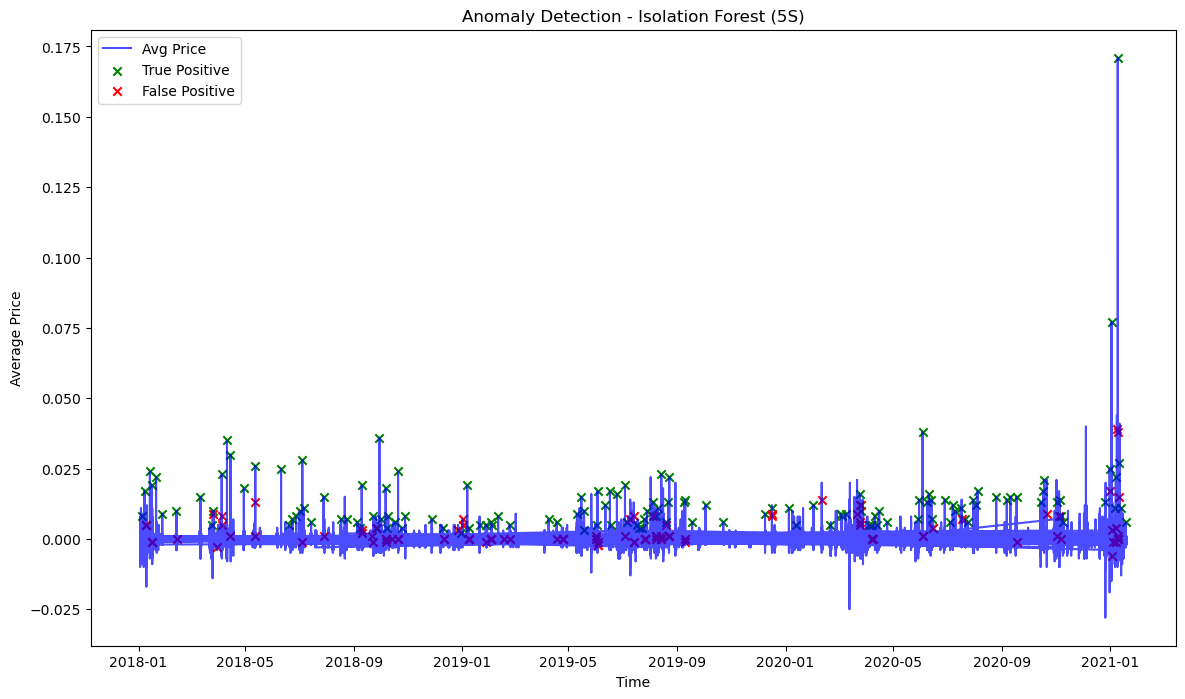

/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


Precision: 0.4404
Recall: 0.5710
F1 Score: 0.4973


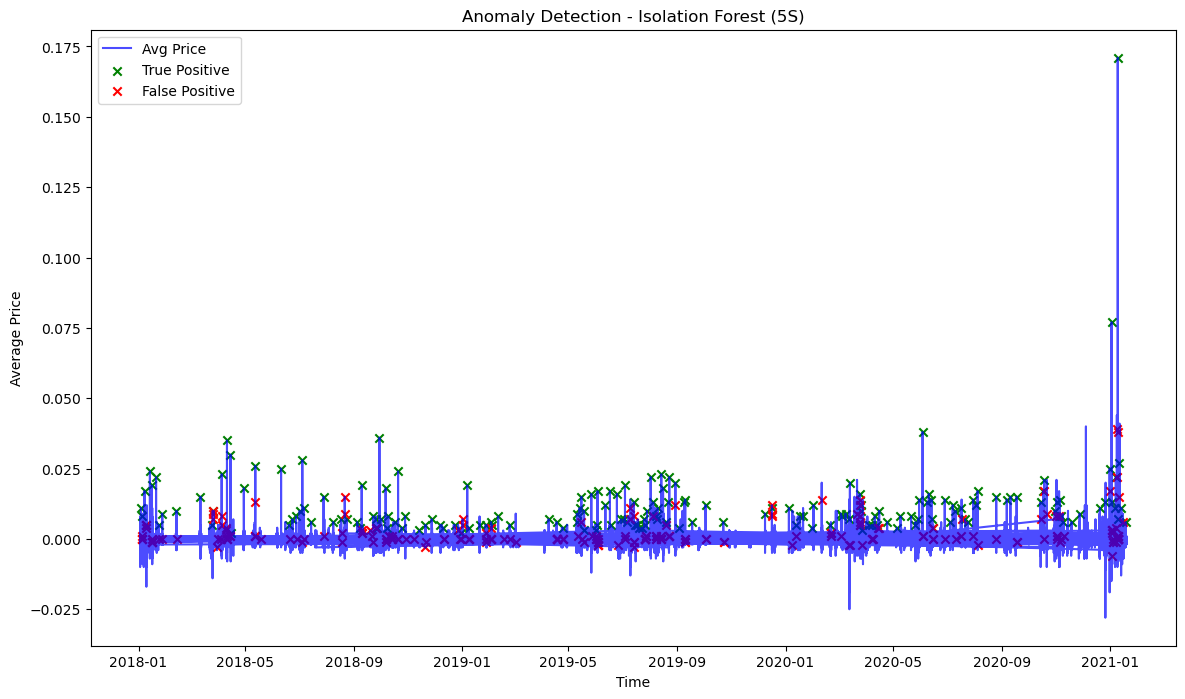

/var/folders/1h/gcmtlw5n24b3nlcvfzpbw5d00000gn/T/ipykernel_24458/1275925209.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({


Precision: 0.2762
Recall: 0.7161
F1 Score: 0.3986


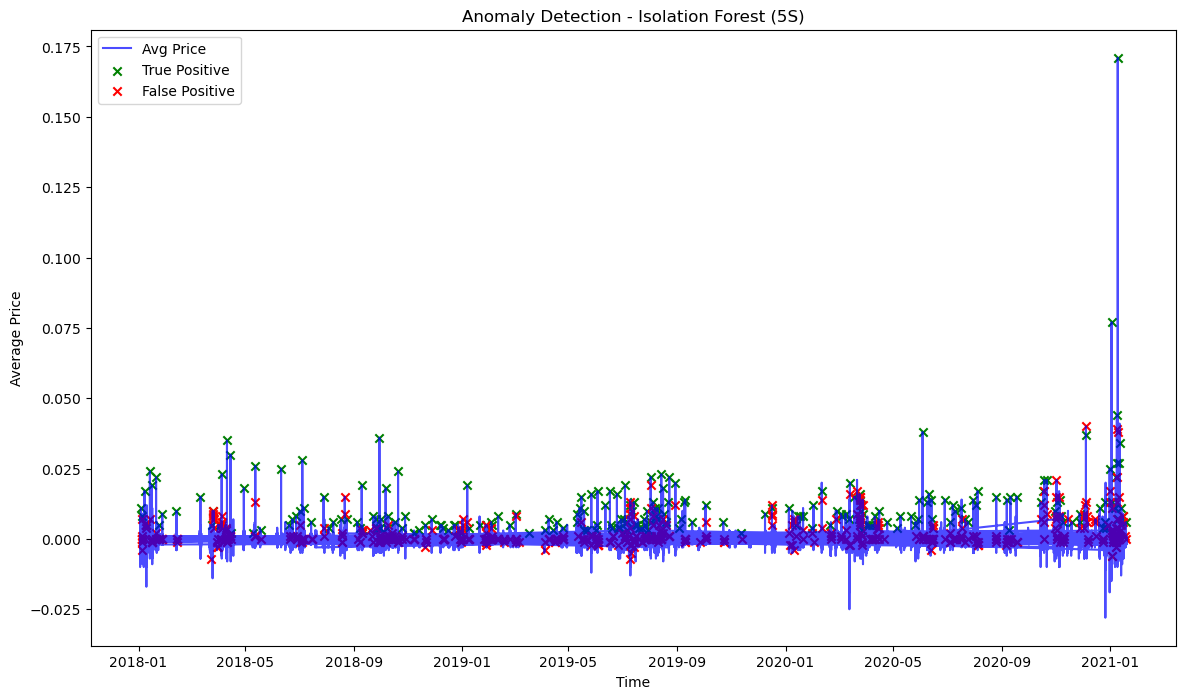

In [12]:
for contamination in [0.00005, 0.0001, 0.0002, 0.0003, 0.0005, 0.001]:
    anom_detx_df = isolation_forest_detector(time_freq='5S', results_df=anom_detx_df, contamination=contamination)

In [13]:
print(f"Total Execution Time: {datetime.datetime.now() - start}")

# Print the results table
print("\nAnomaly Detector Results Table:")
display(anom_detx_df)

Total Execution Time: 0:09:03.380195

Anomaly Detector Results Table:


,Model,Time Frequency,Recall,Precision,F1 Score,Contamination
0,Isolation Forest,25S,0.075710,1.000000,0.140762,0.00005
1,Isolation Forest,25S,0.148265,1.000000,0.258242,0.00010
2,Isolation Forest,25S,0.296530,0.979167,0.455206,0.00020
3,Isolation Forest,25S,0.375394,0.820690,0.515152,0.00030
4,Isolation Forest,25S,0.466877,0.611570,0.529517,0.00050
5,Isolation Forest,25S,0.646688,0.424431,0.512500,0.00100
6,Isolation Forest,15S,0.037855,0.400000,0.069164,0.00005
7,Isolation Forest,15S,0.097792,0.525424,0.164894,0.00010
8,Isolation Forest,15S,0.179811,0.513514,0.266355,0.00020
9,Isolation Forest,15S,0.280757,0.505682,0.361055,0.00030
